<a href="https://colab.research.google.com/github/beecall17/Customer_Segmentation_Analysis/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior


**Goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then report a coherent business story through findings.

## Section 0 — Environment Setup


In [5]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [6]:
# Download the file directly into Colab storage
# Downloading and uploading here took alot of time so instead did directly here.
# !wget "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"

# # # Unzip the file
# !unzip "online+retail+ii.zip"

In [7]:
# Load the dataset
# it extracts an Excel file named 'online_retail_II.xlsx'
df = pd.read_excel('online_retail_II.xlsx',sheet_name='Year 2010-2011')

In [8]:
# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
display("Data shape", df.shape)

# Print dtypes
display(df.info())

'Data shape'

(541910, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


None

In [9]:
# Print first 5 rows
display(df.head())

#print last 5 rows
display(df.tail())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
541909,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [10]:
# Checking on split
df[541800:541810]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
541800,581578,23298,SPOTTY BUNTING,9,2011-12-09 12:16:00,4.95,12713.0,Germany
541801,581578,22993,SET OF 4 PANTRY JELLY MOULDS,12,2011-12-09 12:16:00,1.25,12713.0,Germany
541802,581578,22907,PACK OF 20 NAPKINS PANTRY DESIGN,12,2011-12-09 12:16:00,0.85,12713.0,Germany
541803,581578,22908,PACK OF 20 NAPKINS RED APPLES,12,2011-12-09 12:16:00,0.85,12713.0,Germany
541804,581578,23215,JINGLE BELL HEART ANTIQUE SILVER,12,2011-12-09 12:16:00,2.08,12713.0,Germany
541805,581578,22736,RIBBON REEL MAKING SNOWMEN,10,2011-12-09 12:16:00,1.65,12713.0,Germany
541806,581579,22386,JUMBO BAG PINK POLKADOT,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom
541807,581579,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom
541808,581579,21929,JUMBO BAG PINK VINTAGE PAISLEY,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom
541809,581579,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom


In [11]:
# Check missing values — which columns have nulls? How many?
display(df.isna().sum())

# Null counts in percentage
display(df.isna().sum() / df.shape[0] * 100)

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


,0
Invoice,0.000000
StockCode,0.000000
Description,0.268310
Quantity,0.000000
InvoiceDate,0.000000
Price,0.000000
Customer ID,24.926648
Country,0.000000


In [12]:
# Print basic descriptive statistics
display(df.describe())

,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


In [13]:
# can see (-) negative quanity, so veryfying

# total negative quantity
display("Total negative quantity: ", df.loc[df['Quantity'] < 0, :].shape[0])

# top 2 rows with negative quantity
display("Negative quanity rows: ", df.loc[df['Quantity'] < 0, :].head(2))

'Total negative quantity: '

10624

'Negative quanity rows: '

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom


In [14]:
# Neegative price checking,
display("Total negative price: ", df.loc[df['Price'] < 0, :].shape[0])
display("Negative price rows: ", df.loc[df['Price'] < 0, :])

'Total negative price: '

2

'Negative price rows: '

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [15]:
# Correctly identify rows where 'Customer ID' is NaN
display("Two rows of nan customer id", df.loc[df['Customer ID'].isna(), :].head(2))

'Two rows of nan customer id'

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom


In [16]:
# Grab the first character of every Invoice and count how many of each exist
display(df['Invoice'].astype(str).str[0].value_counts())

,count
Invoice,
5,532619
C,9288
A,3


In [17]:
# Checking total countires and its proportion
display(df["Country"].unique())
display(df["Country"].nunique())
display((df["Country"].value_counts(normalize=True)*100).head(5))

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

38

,proportion
Country,
United Kingdom,91.431788
Germany,1.752136
France,1.579229
EIRE,1.512428
Spain,0.467421


**Initial Observation:**

What do you notice about the data? What surprises you? What problems are already visible?

> This dataset contains 541910 records and 8 features.
No unusal dtypes.

> Records are scattered (no identity of independent records).

> Missing: ~25% of customer id and few 0.26% description

> From describe can see, negative quantity and price. verified them and found `10624 Negative quanity` and `2 negative price`.

> Total 38 countries where 91% of records is from United Kingdom.  


# Section 2 — Data Cleaning

In [18]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# Why? Write your reasoning as a comment before the code
# How many rows are you dropping?
# all the customer 135080 rows, as without the customer id the rest transaction would be hard to identify.
# dropping customer nan will remove the negative price as well, as there were only 2 negative price both on nan customer.
# then after will remove all the remaining negative quantities, as quantity cant be negative its purely typing (record) error.

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
df_clean = df_clean.dropna(subset=['Customer ID'])

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with 'C'
# Why remove them? What would happen if you kept them in Monetary calculation?
# Monetary calcuations will think that all the transaction were completed resulting into monetary or business revenue, but in reality the customer cancelled its order.

# 1. Get the indices of rows where Invoice starts with 'C'
indices_to_drop_starting_c = df_clean[df_clean['Invoice'].astype(str).str.startswith('C', na=False)].index

# 2. Drop those specific indices
df_clean = df_clean.drop(indices_to_drop_starting_c)

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# Kept price >= 0, as in some promotional events there can be free items.
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["Price"] >= 0)]

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# InvoiceDate is already a datetime shape, still did this

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice = Quantity * Price
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["Price"]


In [19]:
display("Total duplicated rows: ", df_clean.duplicated().sum())
# keep=False tells pandas: "Show me EVERY copy of the duplicate rows"
all_duplicates = df_clean[df_clean.duplicated(keep=False)]

# Sort by Invoice and StockCode so the identical twins sit right next to each other
display(all_duplicates.sort_values(by=['Invoice', 'StockCode']).head(4))

# ── Step 6: Remove duplicated rows ───────────────────────────────

df_clean = df_clean.drop_duplicates()

'Total duplicated rows: '

np.int64(5192)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95


In [20]:
# Summary — print shape before and after, and rows lost at each step
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

Original shape: (541910, 8)
Clean shape: (392733, 9)
Rows removed: 149177


## Section 3 — Feature Engineering: Building the Customer Matrix


**Features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer
- **Average basket size**

In [21]:
from datetime import timedelta
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose a reference date for Recency calculation

# To calculate the recency, we need the positive date. If we only use max date
# of invoice we will have 0 recency for the customers who purchased on the last date.
# To mitigate that, I have added 1 extra day using timedelta so the customer would have
# at least 1 day of recency.
reference_date =  df['InvoiceDate'].max() + timedelta(days=1)

# ── Recency ──────────────────────────────────────────────────────────────────
# Days since last purchase per customer
recency = df_clean.groupby('Customer ID')['InvoiceDate'].apply(lambda x: (reference_date -x.max()).days)

# ── Frequency ────────────────────────────────────────────────────────────────
# Number of unique invoices per customer
frequency = df_clean.groupby('Customer ID')['Invoice'].nunique()

# ── Monetary ─────────────────────────────────────────────────────────────────
# Total spend per customer
monetary = df_clean.groupby('Customer ID')['TotalPrice'].sum()

# ── Average basket size ──────────────────────────────────────────────────────
# To do this, first we have find the total item per invoice
basket = df_clean.groupby(['Customer ID', 'Invoice'])['Quantity'].sum()

# then average
basket_average = basket.groupby('Customer ID').mean()

# ── Combine into customer matrix ─────────────────────────────────────────────
# customer_df should have columns: CustomerID, Recency, Frequency, Monetary
# (+ any extra features you engineered)
customer_df = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary,
    'Basket Average' : basket_average
})

# Move Customer ID from the index back to a regular column
customer_df = customer_df.reset_index()

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
display(customer_df.head())


Customer matrix shape: (4339, 5)
Unique customers in clean data: 4339
These numbers should match.


,Customer ID,Recency,Frequency,Monetary,Basket Average
0,12346.0,326,1,77183.60,74215.000000
1,12347.0,2,7,4310.00,351.142857
2,12348.0,75,4,1797.24,585.250000
3,12349.0,19,1,1757.55,631.000000
4,12350.0,310,1,334.40,197.000000


## Section 3.1 Distribution

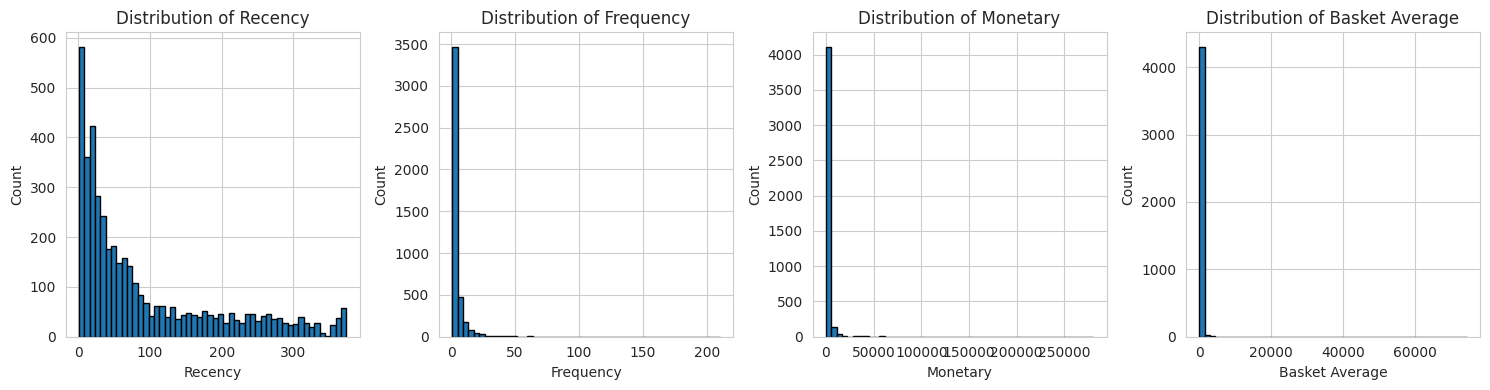

In [22]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

# Raw Distribution

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary', 'Basket Average']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

What do you see in these distributions?
> A heavily right skewed distributions.

Are there outliers? How will they affect clustering?
> There appears to be few high value (monetary and frequency) customers which will pull the centroids towards them resulting into overlapping or non-distict clusters.

In [23]:
import scipy.stats
# Imported to view Shapiro-Wilk p-value of distributions.

In [24]:
features = ['Recency', 'Frequency', 'Monetary', 'Basket Average']

print("--- Raw Distribution Skewness Analysis ---")
for feature in features:
    skewness_val = customer_df[feature].skew()
    shapiro_result = scipy.stats.shapiro(customer_df[feature])

    print(f"\nFeature: {feature}")
    print(f"  Skewness: {skewness_val:.4f}")
    print(f"  Shapiro-Wilk p-value: {shapiro_result.pvalue:.4e}")

--- Raw Distribution Skewness Analysis ---

Feature: Recency
  Skewness: 1.2464
  Shapiro-Wilk p-value: 1.8654e-57

Feature: Frequency
  Skewness: 12.1000
  Shapiro-Wilk p-value: 8.2266e-82

Feature: Monetary
  Skewness: 19.3414
  Shapiro-Wilk p-value: 1.4280e-88

Feature: Basket Average
  Skewness: 46.7724
  Shapiro-Wilk p-value: 8.4589e-91


In [25]:
# Log Transform Only
customer_df_log = customer_df.copy()
for feature in features:
    customer_df_log[feature] = np.log1p(customer_df_log[feature])

print("--- Log Transform Only Skewness Analysis ---")
for feature in features:
    skewness_val = customer_df_log[feature].skew()
    shapiro_result = scipy.stats.shapiro(customer_df_log[feature])

    print(f"\nFeature: {feature}")
    print(f"  Skewness: {skewness_val:.4f}")
    print(f"  Shapiro-Wilk p-value: {shapiro_result.pvalue:.4e}")

--- Log Transform Only Skewness Analysis ---

Feature: Recency
  Skewness: -0.3787
  Shapiro-Wilk p-value: 7.4500e-31

Feature: Frequency
  Skewness: 1.2089
  Shapiro-Wilk p-value: 1.4613e-52

Feature: Monetary
  Skewness: 0.3637
  Shapiro-Wilk p-value: 5.7450e-18

Feature: Basket Average
  Skewness: -0.3301
  Shapiro-Wilk p-value: 5.8761e-29


--- Visualizing Outliers with Box Plots (Pre-handling) ---


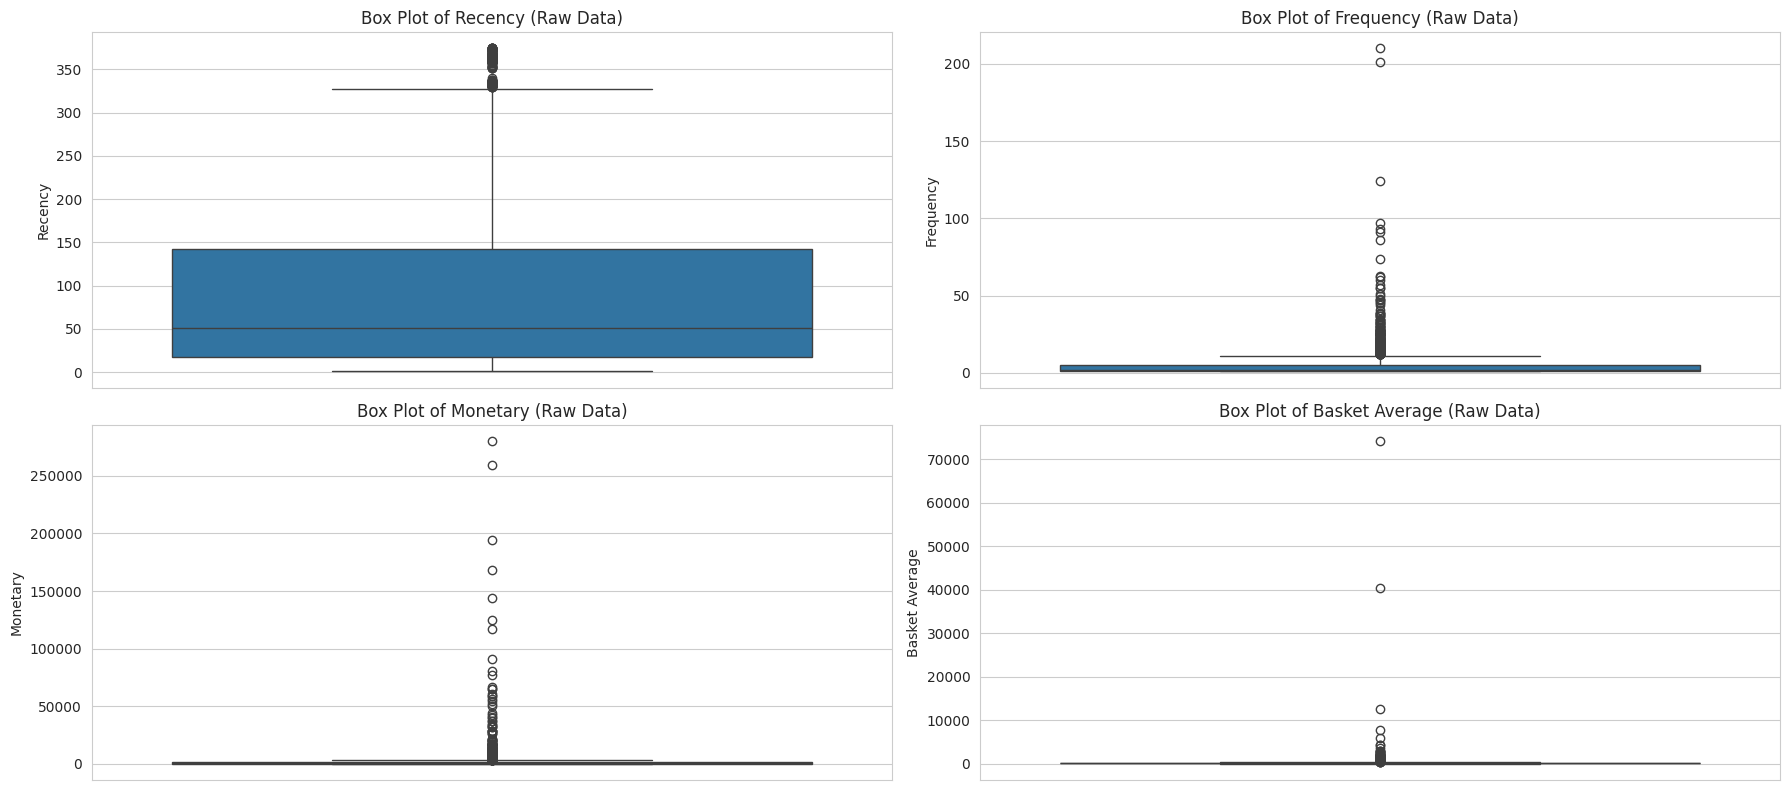

In [26]:
# --- Outlier Detection using IQR ---
# Using the original customer_df to identify outliers before any capping/handling

print("--- Visualizing Outliers with Box Plots (Pre-handling) ---")

plt.figure(figsize=(18, 8))
for i, feat in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=customer_df[feat])
    plt.title(f'Box Plot of {feat} (Raw Data)')
    plt.ylabel(feat)

plt.tight_layout()
plt.show()


**Outlier Handling**

* Based on the initial distribution plots and box plot, all features are right-skewed, with 'Frequency', 'Monetary', and 'Basket Average' showing particularly long tails indicating significant outliers on the higher end.

* 'Recency' also shows some customers with very high recency (not purchased for a long time).

Outliers can disproportionately influence clustering algorithms, leading to poor cluster formation.

*Strategy:*

* For 'Recency', cap values at the 1st and 99th percentile to handle both very recent and very old purchases.
* For 'Frequency', 'Monetary', 'Unique Products', and 'Basket Average', cap values at the 99th percentile as these are heavily right-skewed and we want to reduce the impact of extremely high values without losing too much data.

In [27]:
# ── Outlier Handling ─────────────────────────────────────────────────────────

# Keeping the original customer_df clean
customer_df_outlier_capped = customer_df.copy()

for feat in features:
  if feat == "Recency":
    upper_bounds = customer_df_outlier_capped[feat].quantile(0.99)
    lower_bounds = customer_df_outlier_capped[feat].quantile(0.01)
    customer_df_outlier_capped[feat] = np.clip(customer_df_outlier_capped[feat], lower_bounds, upper_bounds)
    print(f"Capped {feat}: Lower bound at {lower_bounds:.2f}, Upper bound at {upper_bounds:.2f}")
  else:
    upper_bounds = customer_df_outlier_capped[feat].quantile(0.99)
    customer_df_outlier_capped[feat] = np.clip(customer_df_outlier_capped[feat], None, upper_bounds)
    print(f"Capped {feat}: Upper bound at {upper_bounds:.2f}")

Capped Recency: Lower bound at 1.00, Upper bound at 369.00
Capped Frequency: Upper bound at 30.00
Capped Monetary: Upper bound at 19780.27
Capped Basket Average: Upper bound at 1387.54


In [28]:
print("--- Outlier Capped Skewness Analysis ---")

for feat in features:
  skewness_val = customer_df_outlier_capped[feat].skew()
  shapiro_result = scipy.stats.shapiro(customer_df_outlier_capped[feat])

  print(f"\nFeature: {feat}")
  print(f"  Skewness: {skewness_val:.4f}")
  print(f"  Shapiro-Wilk p-value: {shapiro_result.pvalue:.4e}")


--- Outlier Capped Skewness Analysis ---

Feature: Recency
  Skewness: 1.2428
  Shapiro-Wilk p-value: 1.8060e-57

Feature: Frequency
  Skewness: 3.0522
  Shapiro-Wilk p-value: 9.6265e-71

Feature: Monetary
  Skewness: 4.3012
  Shapiro-Wilk p-value: 1.8071e-76

Feature: Basket Average
  Skewness: 2.9232
  Shapiro-Wilk p-value: 2.3461e-65


In [29]:
print("--- Outlier Capped + log transform Skewness Analysis ---")

for feat in features:
  skewness_val = np.log1p(customer_df_outlier_capped[feat]).skew()
  shapiro_result = scipy.stats.shapiro(np.log1p(customer_df_outlier_capped[feat]))

  print(f"\nFeature: {feat}")
  print(f"  Skewness: {skewness_val:.4f}")
  print(f"  Shapiro-Wilk p-value: {shapiro_result.pvalue:.4e}")


--- Outlier Capped + log transform Skewness Analysis ---

Feature: Recency
  Skewness: -0.3791
  Shapiro-Wilk p-value: 6.4100e-31

Feature: Frequency
  Skewness: 1.0043
  Shapiro-Wilk p-value: 1.2005e-51

Feature: Monetary
  Skewness: 0.1699
  Shapiro-Wilk p-value: 5.1214e-13

Feature: Basket Average
  Skewness: -0.6035
  Shapiro-Wilk p-value: 3.7649e-27


## Summary of Feature Distribution and Transformations

**Methodology:**
*   **Raw Distribution:** Original features.
*   **Log Transformation:** The `np.log1p` (log(1+x)) transformation was applied to reduce positive skewness.
*   **Outlier Capping:** Features were capped at the 1st and 99th percentiles (Recency) or 99th percentile (others) to mitigate extreme values.
*   **Capping + Log Transformation:** A combination of outlier capping followed by log transformation.

**Used metrics:** Skewness and Shapiro-Wilk p-values were calculated.

**Findings:**

1.  **Raw Distribution:** All features exhibited extremely high positive skewness and statistically significant non-normality (p-values << 0.05 for Shapiro-Wilk test). This confirms the presence of significant outliers and a distribution unsuitable for direct use in distance-based clustering.
2.  **Log Transformation (Only):** This method significantly reduced the skewness for all features. Monetary, Recency, and Basket Average became much more symmetrical, with Monetary's skewness improving from 19.34 to 0.36. While none achieved statistical normality (p-values still very low), the distributions were much closer to a normal shape.
3.  **Outlier Capping (Only):** Capping alone provided some improvement in skewness for Frequency, Monetary, and Basket Average, but Recency's skewness remained largely unchanged. All features still displayed high non-normality.
4.  **Outlier Capped + Log Transformation:** This combined approach yielded the best statistical metrics for normality, particularly for 'Monetary' (skewness of 0.17, highest p-value). However, for other features, the improvement over 'Log Transformation Only' was marginal.

**Conclusion & Chosen Strategy:**
Based on these analyses, while 'Outlier Capped + Log Transformation' showed slightly better statistical normality metrics, the 'Log Transformation Only' approach is preferred. This decision is driven by the understanding that in customer segmentation, capping extreme outliers might inadvertently remove or dilute information critical for identifying unique, high-value customer segments. A log transformation effectively compresses these extreme values, mitigating their disproportionate influence on clustering algorithms while still preserving their relative magnitude and therefore, their potential to form meaningful clusters. The improved symmetry of the distributions after log transformation makes them more robust for K-Means and similar algorithms.

## Section: 3.2 Feature Scaling
Why is scaling necessary for clustering? Answer in a comment before scaling.

> Scaling is necessary for distance-based clustering algorithms because they rely on distances between data points.
Features with larger numerical ranges would have a disproportionately higher influence on these distance calculations
compared to features with smaller ranges, leading to biased clustering results.
>
> Scaling (`Standard Scaler` is used) standardizes all features
to a similar range (e.g., mean 0, standard deviation 1), ensuring that each feature contributes equally to the distance metric. Where as MinMax scaler caps the values between 0 and 1 which will ruins the cluster formation later as it squashes all normal customer to tiny window and max spending customers sit around 1.


In [30]:
# Apply StandardScaler
scaler = StandardScaler()

# Exclude 'Customer ID' before scaling and store original Customer IDs
customer_ids = customer_df_log['Customer ID']
features_for_scaling = customer_df_log.drop('Customer ID', axis=1)

# Store scaled features as X_scaled (numpy array) and X_scaled_df (DataFrame)
X_scaled = scaler.fit_transform(features_for_scaling)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_scaling.columns, index=customer_ids)

# Verify scaling worked
print("Mean of scaled features:")
print(X_scaled_df.mean().round(2))
print("\nStandard deviation of scaled features:")
print(X_scaled_df.std().round(2))

Mean of scaled features:
Recency           0.0
Frequency         0.0
Monetary         -0.0
Basket Average   -0.0
dtype: float64

Standard deviation of scaled features:
Recency           1.0
Frequency         1.0
Monetary          1.0
Basket Average    1.0
dtype: float64


# Section 4 — Partition Based Clustering
## Section 4.1 K-Means Clustering


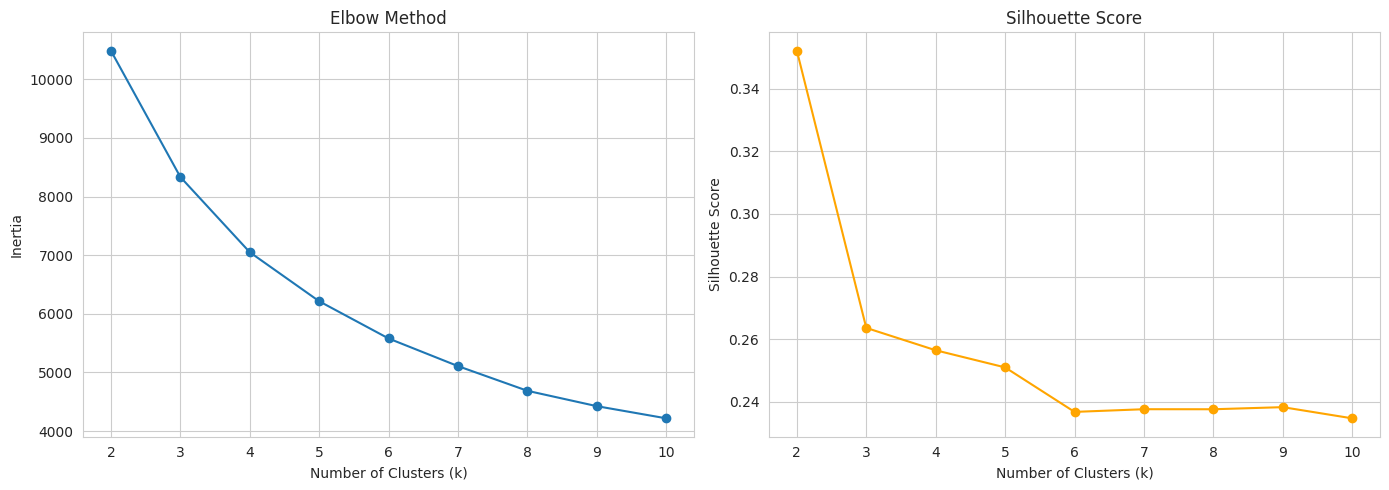

In [31]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_df)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


Do both methods agree? If not, how did you resolve the disagreement?
> Both (Elbow and Sihouette Score) methods doesnt agree with each other. Where Sihouette score suggest the k at 2 results into distince, high quality cluster which sharply drops from k = 3 to 5 then eventually flat out, suggesting less distinct and more overlapping clusters.
Whereas, in elbow method, the drop in inertia is slowed down around K at 4.
>
> Reolving this disagreement comes down to the business consideration. Where at k = 2 we will only get two clusters ('High value' and 'normal' or similar) where as it will not provide granuality on customer segments.

What k did you choose? Why?
> To view differnt customer segments and more granual cluster, I lean towrds K = 4, suggested from the Elbow method.

In [32]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++
# Compare: final inertia, consistency of cluster assignments

OPTIMAL_K = 4
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
  # Random init
  kmeans_random = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=42+i)
  kmeans_random.fit(X_scaled)
  random_inertias.append(kmeans_random.inertia_)

  # K-Means++ init
  kmeans_plusplus = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=42+i)
  kmeans_plusplus.fit(X_scaled)
  kmeanspp_inertias.append(kmeans_plusplus.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"Random std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

Random Init Inertias: [7049.5, 7049.62, 7051.45, 7049.62, 7050.42]
K-Means++ Init Inertias: [7051.52, 7049.67, 7050.97, 7049.62, 7049.84]
Random std: 0.74
K-Means++ std: 0.78


Which initialization is more stable? What does the std tell you?
> The standard deviation (std) of inertia values across multiple runs indicates the stability of the K-Means algorithm's convergence for a given number of clusters (k) and initialization method. A lower std suggests more consistent results.
>
> Based on the std values, k=2 offers the most stable and consistent clustering solution. While k=4 is not as stable as k=2, its std values are significantly lower than k=3 or k=5+, indicating a relatively stable outcome, especially when considering the business need for more granular customer segments. Therefore, k=4 can be considered a reasonably stable choice that balances statistical consistency with practical business requirements for segmentation.
>
> In stable K = 2 the std of random was behind 0.08 than K means++ (Kmeans++ was better at stability than random) and in K = 4, the random looks slightly better than k means++ with 0.04 points.

In [33]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k
import time

start = time.time()
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)
kmeans_time = time.time() - start

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = kmeans.labels_

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary','Basket Average']].mean().round(2)
print("K-Means++ Cluster Profiles:")
print(kmeans_profile)


K-Means++ Cluster Profiles:
                Recency  Frequency  Monetary  Basket Average
KMeans_Cluster                                              
0                179.48       1.44    233.74           79.29
1                120.40       1.99   1089.41          432.22
2                 20.65      12.20   7185.81          355.05
3                 24.00       3.39    797.53          139.31


In [34]:
# ── Step 4:  Mini-Batch K-Means Model ─────────────────────────────────────────
from sklearn.cluster import MiniBatchKMeans
start = time.time()
minibatch_kmeans = MiniBatchKMeans(n_clusters=OPTIMAL_K, batch_size=2048, random_state=42)
minibatch_kmeans.fit(X_scaled)
minibatch_time = time.time() - start

# Assign cluster labels back to customer_df
customer_df['MiniBatch_Cluster'] = minibatch_kmeans.labels_

# Cluster profile
minibatch_profile = customer_df.groupby('MiniBatch_Cluster')[['Recency','Frequency','Monetary','Basket Average']].mean().round(2)
print(minibatch_profile)

                   Recency  Frequency  Monetary  Basket Average
MiniBatch_Cluster                                              
0                   134.36       1.78    268.00           69.15
1                    11.52      17.26  10734.06          383.67
2                   144.13       1.52    720.21          377.68
3                    32.99       4.58   1863.90          260.83


In [35]:
print(f"K-Means++ fit time: {kmeans_time:.2f} seconds")
print(f"Mini-Batch K-Means fit time: {minibatch_time:.2f} seconds\n")

print(f"K-Means++ silhouette score: {silhouette_score(X_scaled, kmeans.labels_):.4f}")
print(f"Mini-Batch K-Means silhouette score: {silhouette_score(X_scaled, minibatch_kmeans.labels_):.4f}\n")


from sklearn.metrics import adjusted_rand_score
rand_score = adjusted_rand_score(customer_df['KMeans_Cluster'], customer_df['MiniBatch_Cluster'])
print(f"Adjusted rand score: {rand_score}")

K-Means++ fit time: 0.08 seconds
Mini-Batch K-Means fit time: 0.01 seconds

K-Means++ silhouette score: 0.2602
Mini-Batch K-Means silhouette score: 0.2407

Adjusted rand score: 0.43959191311909135


>Mini-Batch K-Means was significantly faster, approximately 16 times quicker to train than K-Means++ in this dataset.

>K-Means++ produced a slightly higher Silhouette Score, indicating marginally better-defined and more separated clusters compared to Mini-Batch K-Means.

> Comparing the cluster profiles (kmeans_profile vs. minibatch_profile) reveals differences in how the algorithms grouped customers, particularly for high-value segments. For instance, Mini-Batch K-Means identified a cluster (Cluster 1) with an even higher average Monetary value (10734.06) than the highest monetary cluster from K-Means++ (7185.81). This suggests that while both identify segments, they might partition customers, especially those at the extreme ends, differently.

>An Adjusted Rand Score of 0.4396 indicates a moderate level of agreement between the clustering results of K-Means++ and Mini-Batch K-Means. This means that while there's some similarity in how they group customers, they are not producing identical or nearly identical cluster assignments. The differences in cluster profiles further support this moderate agreement.


>> Mini-Batch K-Means offers a substantial speed advantage, which is critical for larger datasets. While it yielded a slightly lower Silhouette Score and produced moderately different cluster assignments (as shown by the Adjusted Rand Score) compared to K-Means++, its ability to identify distinct high-value segments (e.g., Cluster 1 in Mini-Batch -- loyal, high spenders) might still be valuable depending on specific business objectives. The choice between them involves a trade-off between computational efficiency and marginal differences in cluster quality and composition.



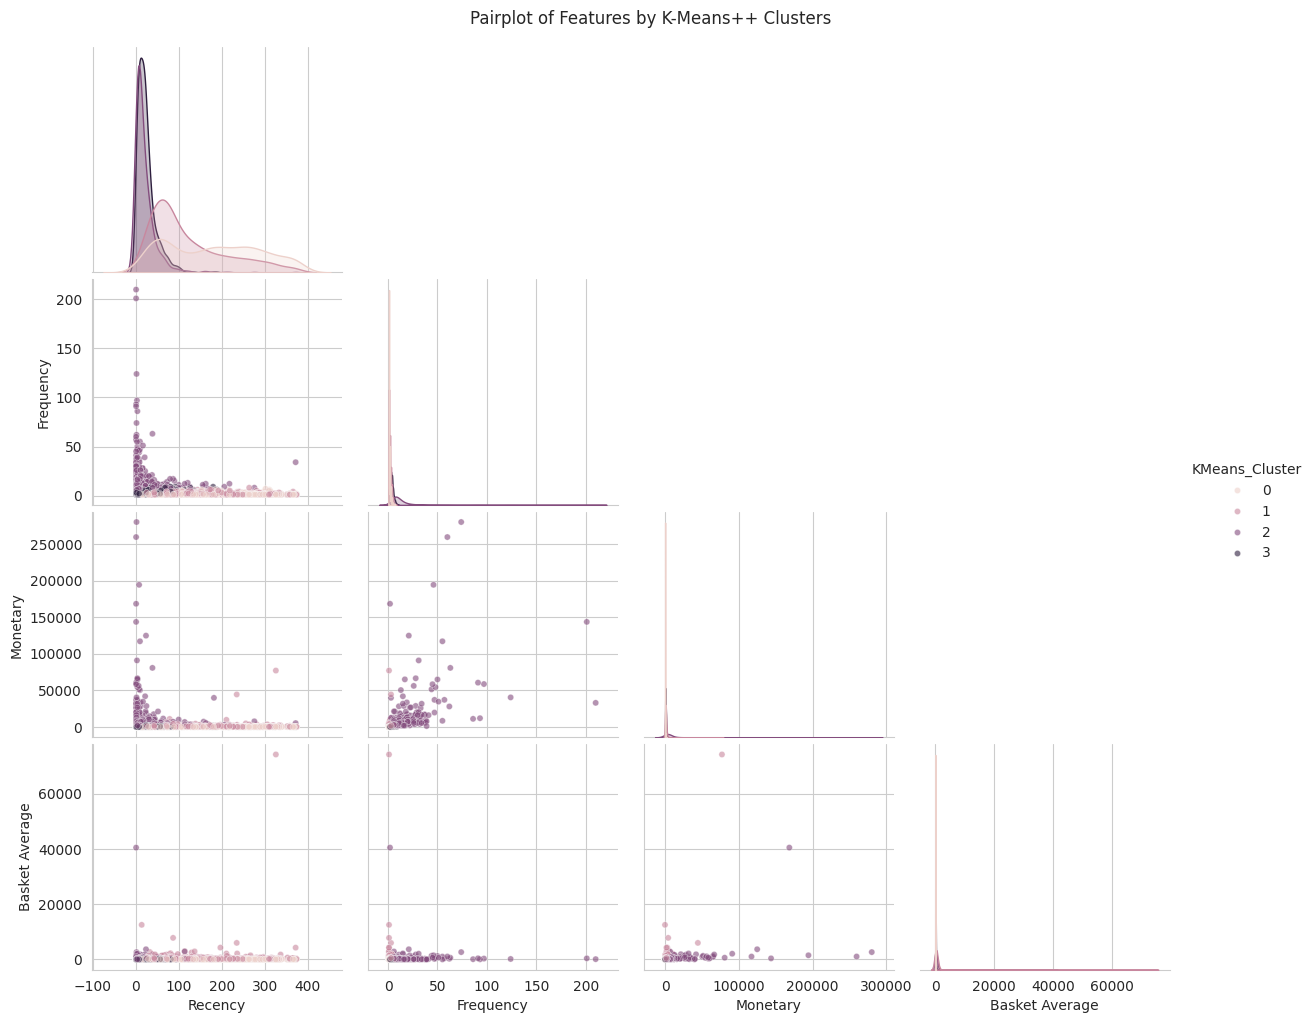

In [36]:
# Pairplot for K-Means++ Clusters
g = sns.pairplot(customer_df, hue='KMeans_Cluster', vars=['Recency', 'Frequency', 'Monetary', 'Basket Average'],
                 height=2.5, aspect=1.2, diag_kind='kde', corner=True,
                 plot_kws={'alpha': 0.6, 's': 20})
g.fig.suptitle('Pairplot of Features by K-Means++ Clusters', y=1.02)
plt.show()

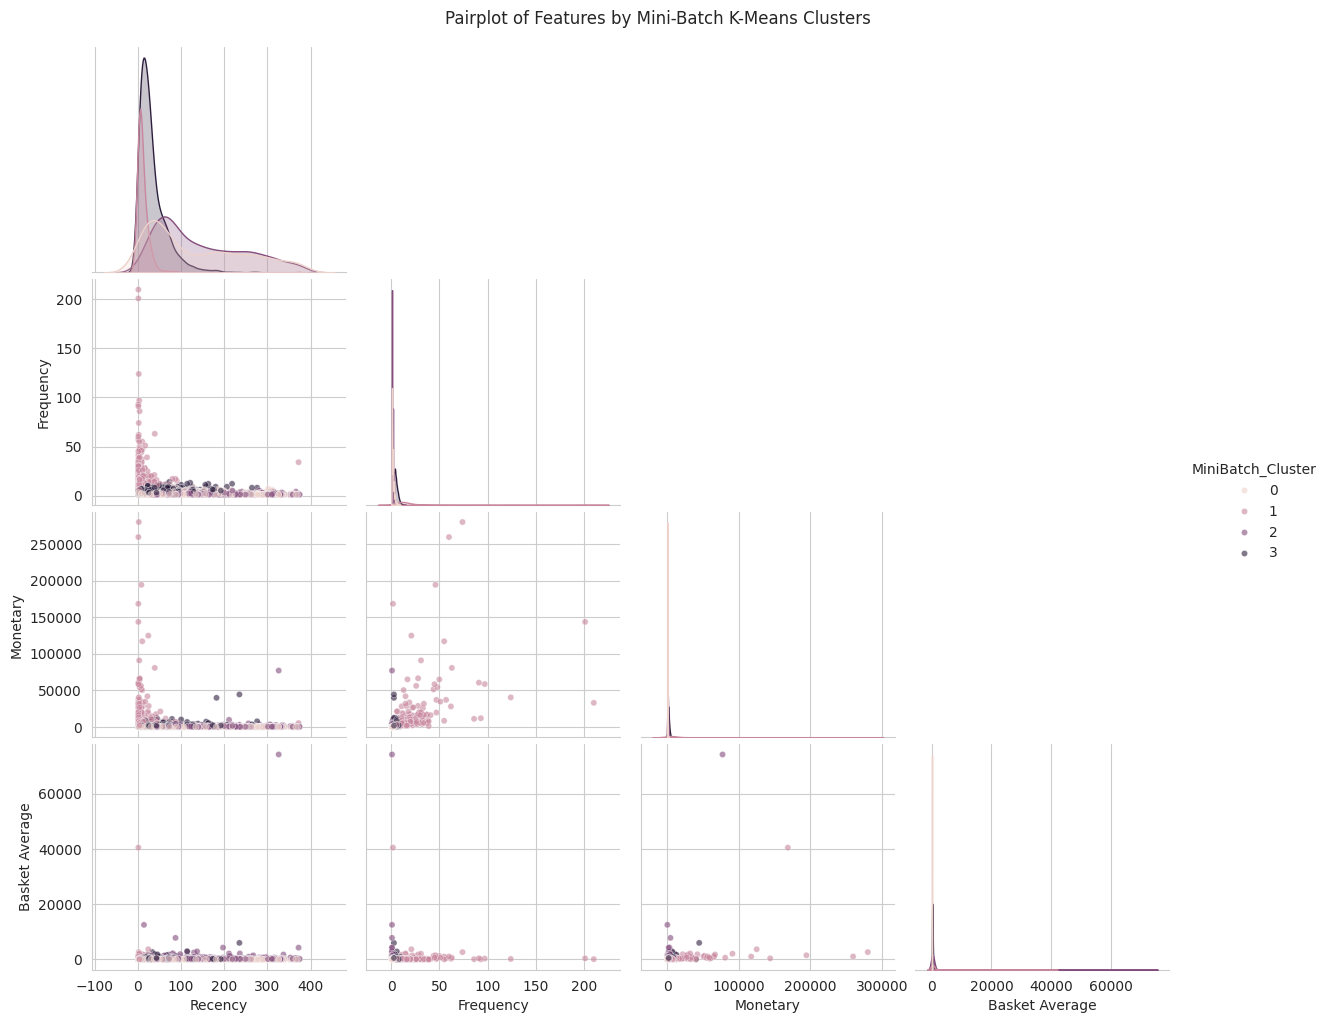

In [37]:
# Pairplot for Mini-Batch K-Means Clusters
g = sns.pairplot(customer_df, hue='MiniBatch_Cluster', vars=['Recency', 'Frequency', 'Monetary', 'Basket Average'],
                 height=2.5, aspect=1.2, diag_kind='kde', corner=True,
                 plot_kws={'alpha': 0.6, 's': 20})
g.fig.suptitle('Pairplot of Features by Mini-Batch K-Means Clusters', y=1.02)
plt.show()

* K-Means++: Visually, the K-Means++ clusters often appear slightly more distinct and compact in various feature pairs, particularly in the lower-value regions. For instance, in 'Recency vs Frequency', the clusters show clearer boundaries. This aligns with the slightly higher Silhouette Score obtained by K-Means++ (0.2602 vs 0.2407).
* Mini-Batch K-Means: While generally similar, some Mini-Batch K-Means clusters might show a bit more overlap or less defined boundaries, especially between the larger, lower-value segments. However, for high-value customers (e.g., high Monetary and Frequency), Mini-Batch K-Means seems to isolate a distinct, smaller cluster (often depicted with a unique color in the far-right/top regions of the plots, matching the earlier profile observation of Cluster 1 having a high average Monetary value).
* High-Value Customer Segmentation:
Both algorithms identify distinct segments of high-value customers (high Monetary, high Frequency, low Recency). However, the exact composition and boundaries of these high-value clusters differ. Mini-Batch K-Means seems to have a cluster (as observed in its profile) that aggregates extremely high monetary values more intensely than K-Means++.

* Overall Distribution:
The general shapes and spreads of the clusters across all feature pairs are broadly similar for both algorithms, which is expected given the moderate Adjusted Rand Score of 0.4396. This score indicates that while they are not identical, they capture some similar underlying structures in the data

## Section 5 — Hierarchical Clustering


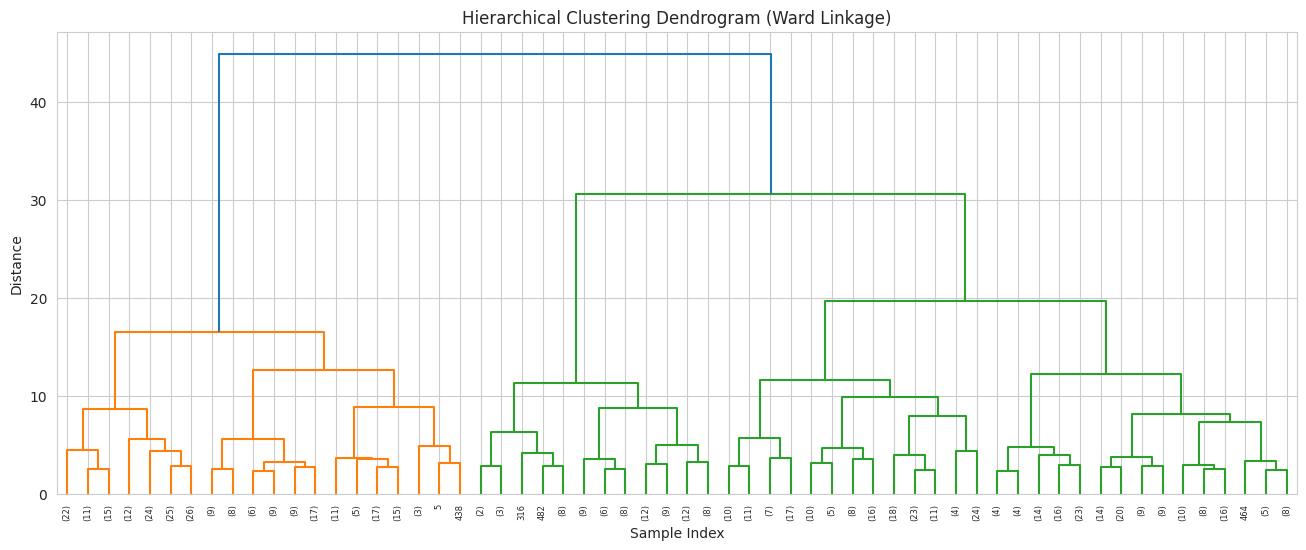

In [38]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Justify your sample size in a comment
# Taken 15% of Data i.e., 4339*0.15 = 650.85
SAMPLE_SIZE = 650  # adjust if needed
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix — try 'ward' first
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=60, show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

**Where did you cut the dendrogram? Why? How many clusters does this suggest?**
> By observing the dendrogram with Ward linkage, a horizontal cut at a distance of approximately **20** suggests **4 distinct clusters**. This cut point is chosen because it effectively separates four major branches that maintain significant distances from each other before further merging. Although the height in left side (2nd shows small height) seperating them would result into distinct cluster.

In [39]:
# ── Step 2: Fit Agglomerative Clustering Variants ────────────────────────────

N_CLUSTERS_HIER = 4 # Based on dendrogram analysis from previous step

# --- 1. Standard Agglomerative Clustering (Ward Linkage) ---
# This is the baseline hierarchical clustering method.
start_time_ward_agg = time.time()
agg_ward_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
agg_ward_labels = agg_ward_model.fit_predict(X_scaled)
end_time_ward_agg = time.time()
agg_ward_time = end_time_ward_agg - start_time_ward_agg

# --- 2. Agglomerative Clustering with K-Neighbors Graph (Ward Linkage) ---
# This method constrains clustering to only merge adjacent points based on a connectivity graph.
# It can prevent 'chaining' and enforce more local clusters.
from sklearn.neighbors import kneighbors_graph

start_time_kgraph_agg = time.time()
# Create a connectivity graph (e.g., 5 nearest neighbors, chosen to reflect local density)
# `include_self=False` means a point is not considered its own neighbor.
connectivity_matrix = kneighbors_graph(X_scaled, n_neighbors=5, include_self=False)

# Pass the connectivity matrix to Agglomerative Clustering
agg_kgraph_ward_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward', connectivity=connectivity_matrix)
agg_kgraph_ward_labels = agg_kgraph_ward_model.fit_predict(X_scaled)
end_time_kgraph_agg = time.time()
agg_kgraph_ward_time = end_time_kgraph_agg - start_time_kgraph_agg

# --- 3. BIRCH Clustering (Standalone) ---
# BIRCH is designed for large datasets, creating a CF-tree (Clustering Feature Tree) in memory.
# It performs a single pass over the data.
start_time_birch_standalone = time.time()
birch_model = Birch(n_clusters=N_CLUSTERS_HIER)
birch_labels = birch_model.fit_predict(X_scaled)
end_time_birch_standalone = time.time()
birch_standalone_time = end_time_birch_standalone - start_time_birch_standalone

# --- 4. BIRCH as Preprocessor + Agglomerative Clustering ---
# This is a hybrid approach where BIRCH first summarizes the data into subclusters,
# and then Agglomerative Clustering is applied to these smaller set of subclusters.
# This greatly reduces computational cost for hierarchical clustering on large datasets.
start_time_birch_agg_combined = time.time()
# `n_clusters=None` means BIRCH will find an arbitrary number of subclusters based on `threshold` and `branching_factor`
birch_preprocessor = Birch(threshold=0.5, branching_factor=50, n_clusters=None)
birch_preprocessor.fit(X_scaled)

# Extract the centers of the subclusters found by BIRCH
X_birch_summarized = birch_preprocessor.subcluster_centers_

# Apply Agglomerative Clustering on the summarized data
agg_birch_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
agg_birch_labels_on_summarized = agg_birch_model.fit_predict(X_birch_summarized)

# To get labels for original data points, map the BIRCH subclusters to their final Agglomerative clusters.
# Each original point belongs to a BIRCH subcluster, which then belongs to an Agglomerative cluster.
original_to_subcluster_map = birch_preprocessor.predict(X_scaled)
birch_agg_combined_labels = agg_birch_labels_on_summarized[original_to_subcluster_map]
end_time_birch_agg_combined = time.time()
birch_agg_combined_time = end_time_birch_agg_combined - start_time_birch_agg_combined

# Assign labels to customer_df for further analysis (if needed in subsequent cells)
customer_df['Hierarchical_Ward'] = agg_ward_labels
customer_df['Hierarchical_Ward_KGraph'] = agg_kgraph_ward_labels
customer_df['Hierarchical_BIRCH'] = birch_labels
customer_df['Hierarchical_BIRCH_Agg'] = birch_agg_combined_labels

# ── Consolidated Results Output ──────────────────────────────────────────
print("\n--- Hierarchical Clustering Performance ---")

# Execution Times
print(f"Agglomerative Clustering (Standard Ward) execution time: {agg_ward_time:.4f} seconds")
print(f"Agglomerative Clustering (Ward with K-Graph) execution time: {agg_kgraph_ward_time:.4f} seconds")
print(f"BIRCH Clustering (Standalone) execution time: {birch_standalone_time:.4f} seconds")
print(f"Agglomerative Clustering (BIRCH + Agg Combined) execution time: {birch_agg_combined_time:.4f} seconds")

# Silhouette Scores (Cluster Quality)
print("\n--- Silhouette Scores ---")
print(f"Standard Ward linkage silhouette score: {silhouette_score(X_scaled, agg_ward_labels):.4f}")
print(f"Ward linkage with K-Graph silhouette score: {silhouette_score(X_scaled, agg_kgraph_ward_labels):.4f}")
print(f"BIRCH standalone silhouette score: {silhouette_score(X_scaled, birch_labels):.4f}")
print(f"BIRCH + Agg combined silhouette score: {silhouette_score(X_scaled, birch_agg_combined_labels):.4f}")

# Adjusted Rand Scores (Comparison to Standard Ward as Baseline)
# This measures the similarity between the different clustering results and the baseline.
print("\n--- Adjusted Rand Scores (vs. Standard Ward) ---")
print(f"Adjusted Rand Score (Standard Ward vs. K-Graph Ward): {adjusted_rand_score(agg_ward_labels, agg_kgraph_ward_labels):.4f}")
print(f"Adjusted Rand Score (Standard Ward vs. BIRCH Standalone): {adjusted_rand_score(agg_ward_labels, birch_labels):.4f}")
print(f"Adjusted Rand Score (Standard Ward vs. BIRCH + Agg Combined): {adjusted_rand_score(agg_ward_labels, birch_agg_combined_labels):.4f}")

print(f"\nOriginal data points: {X_scaled.shape[0]}, Summarized data points by BIRCH: {X_birch_summarized.shape[0]}")


--- Hierarchical Clustering Performance ---
Agglomerative Clustering (Standard Ward) execution time: 2.2221 seconds
Agglomerative Clustering (Ward with K-Graph) execution time: 0.2416 seconds
BIRCH Clustering (Standalone) execution time: 0.1416 seconds
Agglomerative Clustering (BIRCH + Agg Combined) execution time: 0.1706 seconds

--- Silhouette Scores ---
Standard Ward linkage silhouette score: 0.2172
Ward linkage with K-Graph silhouette score: 0.1975
BIRCH standalone silhouette score: 0.1751
BIRCH + Agg combined silhouette score: 0.1751

--- Adjusted Rand Scores (vs. Standard Ward) ---
Adjusted Rand Score (Standard Ward vs. K-Graph Ward): 0.3181
Adjusted Rand Score (Standard Ward vs. BIRCH Standalone): 0.1866
Adjusted Rand Score (Standard Ward vs. BIRCH + Agg Combined): 0.1866

Original data points: 4339, Summarized data points by BIRCH: 266


> While BIRCH and K-Graph methods offer clear advantages in terms of computational speed, they resulted in lower Silhouette Scores and produced cluster assignments that were notably different from the standard Agglomerative Ward linkage.

 >For this dataset, prioritizing cluster quality and interpretability, we will continue with the Standard Agglomerative Ward linkage, accepting the trade-off of a longer execution time for potentially more robust and meaningful customer segments.



In [40]:
# ── Step 3: Compare Linkage Methods (Complete, Single, Average) ────────────────

# --- 1. Agglomerative Clustering with Complete Linkage ---
# Complete linkage merges clusters based on the maximum distance between any points in the clusters.
agg_complete_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
agg_complete_labels = agg_complete_model.fit_predict(X_scaled)

# --- 2. Agglomerative Clustering with Single Linkage ---
# Single linkage merges clusters based on the minimum distance between any points in the clusters.
# This method is prone to 'chaining' where clusters are stretched out.
agg_single_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='single')
agg_single_labels = agg_single_model.fit_predict(X_scaled)

# --- 3. Agglomerative Clustering with Average Linkage ---
# Average linkage merges clusters based on the average distance between all points in the clusters.
agg_average_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='average')
agg_average_labels = agg_average_model.fit_predict(X_scaled)

# Assign labels to customer_df for further analysis
customer_df['Hierarchical_Complete'] = agg_complete_labels
customer_df['Hierarchical_Single'] = agg_single_labels
customer_df['Hierarchical_Average'] = agg_average_labels

# ── Consolidated Results Output for Linkage Methods ──────────────────────────
print("\n--- Hierarchical Clustering Linkage Method Comparison ---")

# Cluster Sizes (distribution of points within each cluster)
print("\n--- Cluster Sizes ---")
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("\nComplete linkage cluster sizes:")
print(customer_df['Hierarchical_Complete'].value_counts())
print("\nSingle linkage cluster sizes:")
print(customer_df['Hierarchical_Single'].value_counts())
print("\nAverage linkage cluster sizes:")
print(customer_df['Hierarchical_Average'].value_counts())

# Silhouette Scores (Cluster Quality)
print("\n--- Silhouette Scores ---")
print(f"Ward linkage silhouette score: {silhouette_score(X_scaled, agg_ward_labels):.4f}")
print(f"Complete linkage silhouette score: {silhouette_score(X_scaled, agg_complete_labels):.4f}")
print(f"Single linkage silhouette score: {silhouette_score(X_scaled, agg_single_labels):.4f}")
print(f"Average linkage silhouette score: {silhouette_score(X_scaled, agg_average_labels):.4f}")

# Adjusted Rand Scores (Comparison to Ward as Baseline)
print("\n--- Adjusted Rand Scores (vs. Ward Linkage) ---")
print(f"Adjusted Rand Score (Ward vs. Complete): {adjusted_rand_score(agg_ward_labels, agg_complete_labels):.4f}")
print(f"Adjusted Rand Score (Ward vs. Single): {adjusted_rand_score(agg_ward_labels, agg_single_labels):.4f}")
print(f"Adjusted Rand Score (Ward vs. Average): {adjusted_rand_score(agg_ward_labels, agg_average_labels):.4f}")


--- Hierarchical Clustering Linkage Method Comparison ---

--- Cluster Sizes ---
Ward linkage cluster sizes:
Hierarchical_Ward
2    1322
0    1192
1    1037
3     788
Name: count, dtype: int64

Complete linkage cluster sizes:
Hierarchical_Complete
0    2922
1    1413
2       3
3       1
Name: count, dtype: int64

Single linkage cluster sizes:
Hierarchical_Single
0    4336
3       1
1       1
2       1
Name: count, dtype: int64

Average linkage cluster sizes:
Hierarchical_Average
0    4314
1      21
2       3
3       1
Name: count, dtype: int64

--- Silhouette Scores ---
Ward linkage silhouette score: 0.2172
Complete linkage silhouette score: 0.2577
Single linkage silhouette score: 0.6398
Average linkage silhouette score: 0.5581

--- Adjusted Rand Scores (vs. Ward Linkage) ---
Adjusted Rand Score (Ward vs. Complete): 0.2002
Adjusted Rand Score (Ward vs. Single): 0.0001
Adjusted Rand Score (Ward vs. Average): -0.0002


**Did the two linkage methods produce similar or different cluster structures? Which do you prefer and why?**
> * Single and Average linkages are problematic for this dataset, leading to severely imbalanced clusters where almost all data points fall into a single large cluster. Despite numerically high Silhouette Scores, the resulting clusters are not useful for segmentation. The Adjusted Rand Scores confirm their results are vastly different from Ward.
>
>* Complete linkage, while achieving a slightly higher Silhouette Score than Ward, also suffered from significant cluster imbalance, with most points in two large clusters and very few in others. This makes it less desirable for generating meaningful, distinct customer segments.
> * Ward linkage stands out by providing a much more balanced distribution of data points across its 4 clusters. Although its Silhouette Score is not the highest, the more equitable distribution of customers into distinct groups is typically more valuable for practical customer segmentation.

>Therefore, I choose Ward linkage for this dataset, prioritizing a reasonable and interpretable distribution of clusters over potentially misleading higher Silhouette Scores from methods that create highly skewed cluster sizes. The goal is meaningful segmentation, not just numerically optimal scores in isolation.

In [41]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary','Basket Average']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)


kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary','Basket Average']].mean().round(2)
print("\nKmeans Clustering Profiles:")
print(kmeans_profile)

Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary  Basket Average
Hierarchical_Ward                                              
0                    26.23      10.36   5590.54          277.84
1                    85.93       1.93   1309.90          526.75
2                   198.85       1.77    364.00          106.72
3                    23.07       2.35    486.96          113.24

Kmeans Clustering Profiles:
                Recency  Frequency  Monetary  Basket Average
KMeans_Cluster                                              
0                179.48       1.44    233.74           79.29
1                120.40       1.99   1089.41          432.22
2                 20.65      12.20   7185.81          355.05
3                 24.00       3.39    797.53          139.31


**Comparison of Cluster Profiles: Hierarchical Ward vs. K-Means**

* Hierarchical Ward (Clusters 0, 1): Provides a nuanced separation of high-value customers. Cluster 0 clearly identifies the 'best' customers (recent, frequent, high spend). Cluster 1 isolates 'valuable, less frequent' customers who spend a lot per transaction but don't return as often. This distinction is crucial for targeted retention strategies (e.g., engaging less frequent high-spenders).
* K-Means (Clusters 1, 2, 3): Cluster 2 accurately identifies 'best customers'. K-Means' separation of At-Risk High-Value (Cluster 1) and Promising Engaged (Cluster 3) is also valuable, but Ward appears to offer a more distinct separation of the 'lost loyal, high spender' profile (Ward's Cluster 1) from the 'best' customers.
* Identification of Lost/Churned Customers: Both algorithms effectively identify a Lost/Churned segment (Ward Cluster 2, K-Means Cluster 0), characterized by high recency and low other metrics. These segments are vital for churn prevention campaigns.

 Both methods provide a reasonable level of granularity with 4 clusters. However, based on the profiles, Hierarchical Ward linkage (specifically with Ward's method) seems to offer a slightly clearer and more actionable separation for the 'lost loyal, high spender' and 'valuable, but less frequent' customer types. This improved separation, particularly in the mid-to-high value segments, suggests that Ward's approach creates more distinct and interpretable groups for business strategy, trading off its slightly lower efficiency for better cluster quality for this specific dataset.

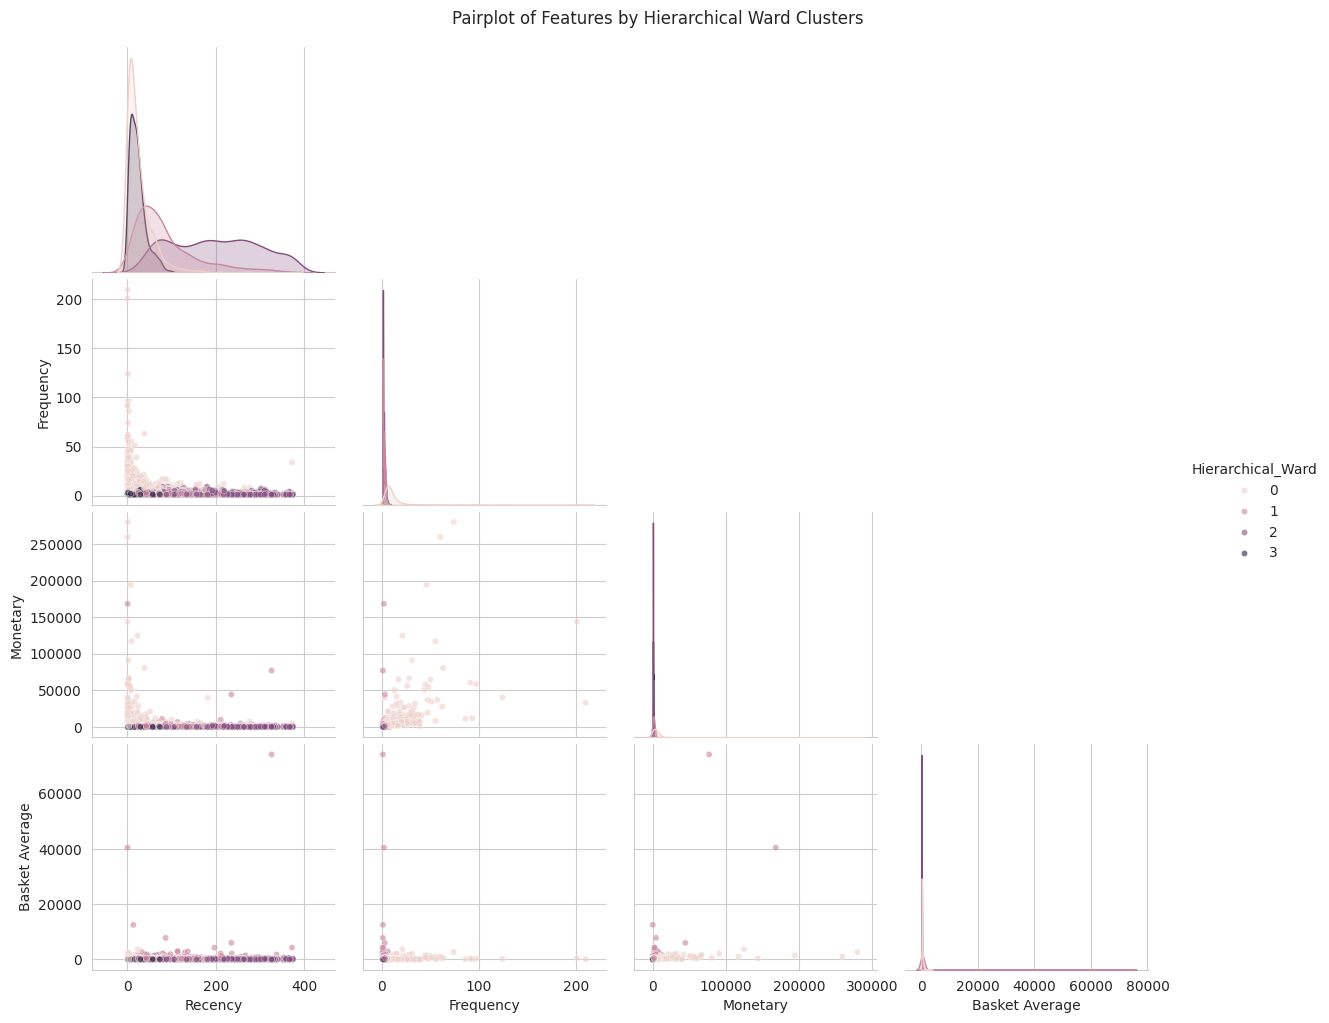

In [42]:
# Visualise choosen Hierarchical Clustering — same axes as K-Means for comparison
g = sns.pairplot(customer_df, hue='Hierarchical_Ward', vars=['Recency', 'Frequency', 'Monetary', 'Basket Average'],
                 height=2.5, aspect=1.2, diag_kind='kde', corner=True,
                 plot_kws={'alpha': 0.6, 's': 20})
g.fig.suptitle('Pairplot of Features by Hierarchical Ward Clusters', y=1.02)
plt.show()

# Section 6 — Density Based Clustering
## Section 6.1 — DBSCAN Clustering

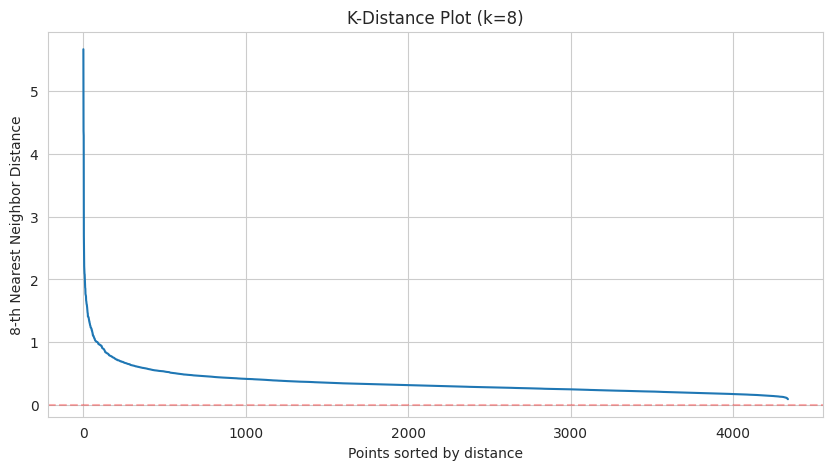

In [47]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 8  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

Where is the elbow in this plot?
What epsilon value does it suggest?
> Followed to test and use 2 * no of features = 8 for min samples, in this plot the elbow is around 0.5-0.7 before flattens out. This suggest somewhere around 0.5-0.7 might be our epsilon value.


In [45]:
# ── Step 2: Run DBSCAN and Experiment ───────────────────────────
# Try different combinations of eps and min_samples
# Record results for each combination

EPSILON_ESTIMATE = 0.6 # From K-Distance Plot

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    # Add your own combinations here
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 8},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 8},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 8},
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 eps  min_samples  n_clusters  n_noise  noise_pct
0.48            5           5      263       6.06
0.60            5           3      126       2.90
0.72            5           2       80       1.84
0.48            8           3      344       7.93
0.60            8           2      176       4.06
0.72            8           1      111       2.56


Which combination did you choose as your final DBSCAN parameters? Why?

> From the experiments and elbow from k-distance, the epsilon at 0.6 is optimal where as, in min_sample the heuristic formula of 2 * D = 8 yeiled high noise and less clusters.
>
> The combination of 0.6 epsilon and 5 min_samples is the optimal balance between number of cluster formed and noise_pct. (3 cluster + 1 noise = 4 cluster, similar to kmeans and Hierarchical Clustering)


In [53]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
MIN_SAMPLES = 5
EPSILON_ESTIMATE = 0.6

dbscan_start = time.time()
db = DBSCAN(eps=EPSILON_ESTIMATE, min_samples=MIN_SAMPLES)
db_labels = db.fit_predict(X_scaled)
dbscan_time = time.time() - dbscan_start

# Assign cluster labels back to customer_df
customer_df['DBSCAN_Cluster'] = db_labels

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print(f"Note: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"Noise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("Noise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary','Basket Average']].describe().round(2))

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    4205
-1     126
 2       5
 1       3
Name: count, dtype: int64
Note: Cluster -1 = Noise Points
Noise customers: 126 (2.9%)
Noise customer profile (mean RFM):
       Recency  Frequency   Monetary  Basket Average
count   126.00     126.00     126.00          126.00
mean     76.67      19.30   23201.89         1856.23
std      99.84      33.88   46511.16         7566.01
min       1.00       1.00       0.00            1.00
25%       4.00       1.00     347.42           17.75
50%      24.00       4.00    3595.07          365.50
75%     120.75      21.75   27807.54         1457.18
max     372.00     210.00  280206.02        74215.00


> From using epsilon 0.6 and min samples 5, the 4 cluster (including noise) showed differnet or like similar to average linkage cluster formation with one cluster 0, dominating the entire data points resulting into imbalance poportion of data points distribution in the clusters. It might have better sihoulet score due to this behaviour.

Who are these noise customers?
Are they outliers (e.g. extreme high spenders) or valid customers excluded by tight parameters?
> Looking at the noise cluster profiles, we can see its the group of `lost loyal high spender`. This clusters groups the customers who were high spenders when they purchased (can verify with basket average) but havent been seen in the business for a long time.

What would you recommend to the business about these customers?
> Losing high-value customers represents a substantial revenue loss and a missed opportunity. For these "lost loyal high spender" noise customers, the business should:
>1.  **Investigate Deeper:** Conduct qualitative research (e.g., surveys, interviews if contactable) to understand the specific reasons for their churn or inactivity. This could reveal systemic issues or changes in customer needs.
>2.  **Personalized Retention Efforts:** Develop highly personalized and tailored retention campaigns. Given their past high spending, a generic discount might not be enough. Consider:
    *   **Exclusive offers:** Special access to new products, VIP discounts, or unique experiences.
    *   **Win-back campaigns:** Targeted emails or direct mail acknowledging their past value and offering incentives to return.
    *   **Customer service outreach:** Proactive calls or messages from dedicated account managers to understand their needs and address any grievances.
3.  **Feedback Loop:** Establish a clear process to collect feedback from these lapsed high-value customers, even if they don't return immediately. Understanding their preferences and pain points can inform future strategies for all customer segments.

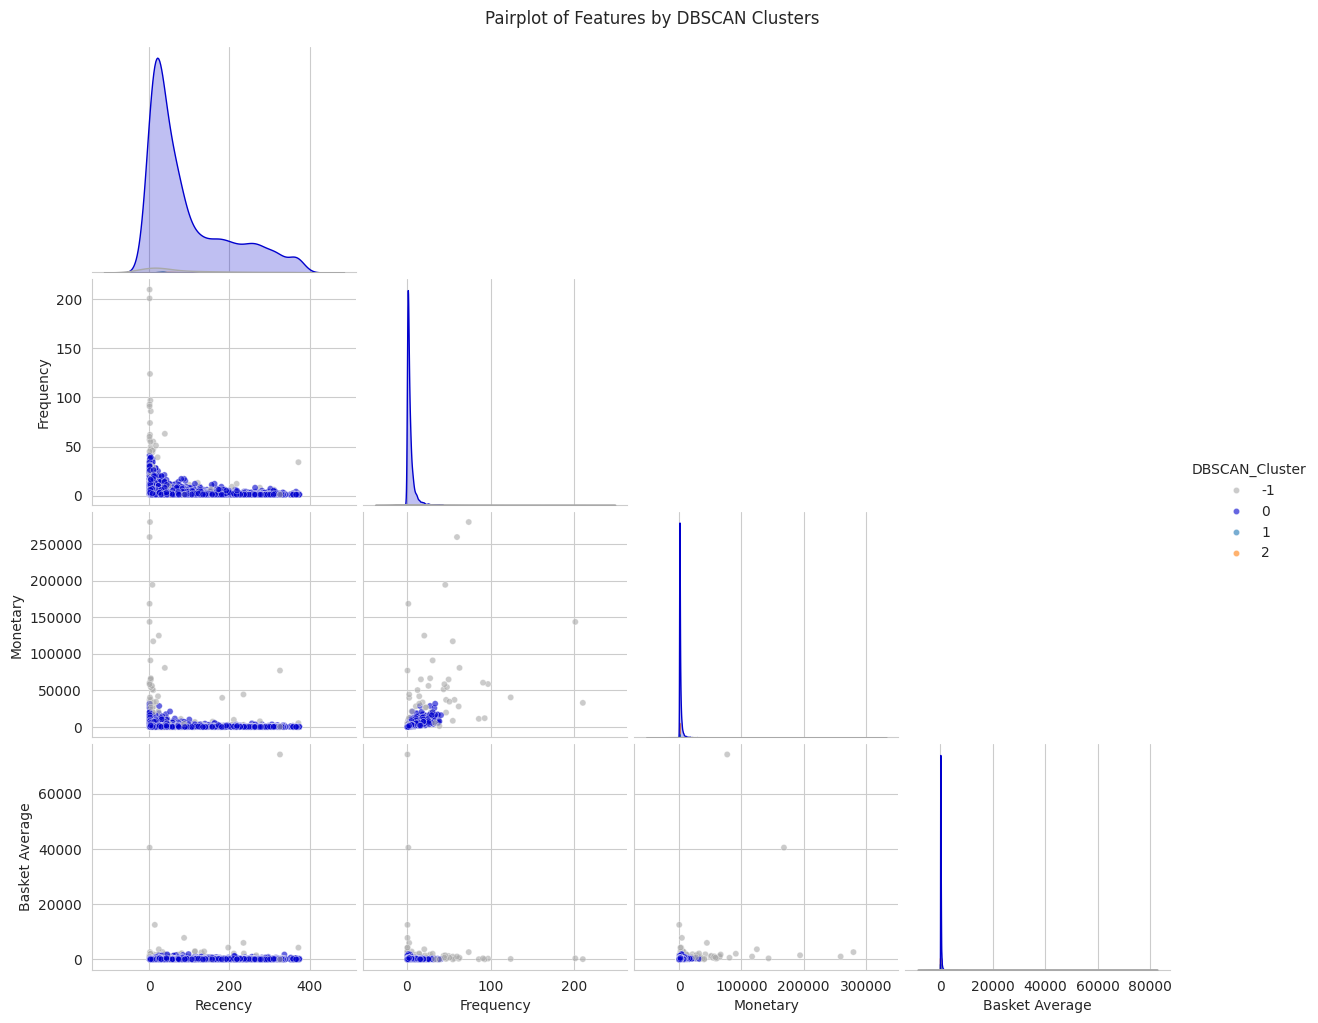

In [58]:
# Visualise DBSCAN Clusters with better color distinction

# Get unique cluster labels from DBSCAN
dbscan_unique_clusters = sorted(customer_df['DBSCAN_Cluster'].unique())

# Create a custom palette
palette_dbscan = {}
# Assign a distinct color for noise (-1)
palette_dbscan[-1] = 'darkgrey'

# Use a colorblind-friendly palette for the actual clusters
# Adjust this as needed based on the number of actual clusters (excluding noise)
# If there are only a few non-noise clusters, pick contrasting colors.
# Example for 3 non-noise clusters (0, 1, 2) from `results_df` shows 3 or 5 clusters, in this case it is 3.
non_noise_clusters = [label for label in dbscan_unique_clusters if label != -1]
if len(non_noise_clusters) > 0:
    # Assign a prominent color to the main cluster (0)
    if 0 in non_noise_clusters:
        palette_dbscan[0] = 'mediumblue'
        remaining_clusters = [c for c in non_noise_clusters if c != 0]
    else:
        remaining_clusters = non_noise_clusters

    # Use a sequential or divergent palette for other clusters
    # Number of colors needed for remaining clusters
    num_remaining = len(remaining_clusters)
    if num_remaining > 0:
        other_colors = sns.color_palette('tab10', n_colors=num_remaining)
        for i, cluster_id in enumerate(remaining_clusters):
            palette_dbscan[cluster_id] = other_colors[i]


g = sns.pairplot(customer_df, hue='DBSCAN_Cluster', vars=['Recency', 'Frequency', 'Monetary', 'Basket Average'],
                 height=2.5, aspect=1.2, diag_kind='kde', corner=True,
                 plot_kws={'alpha': 0.6, 's': 20},
                 palette=palette_dbscan) # Apply the custom palette
g.fig.suptitle('Pairplot of Features by DBSCAN Clusters', y=1.02) # Corrected title
plt.show()


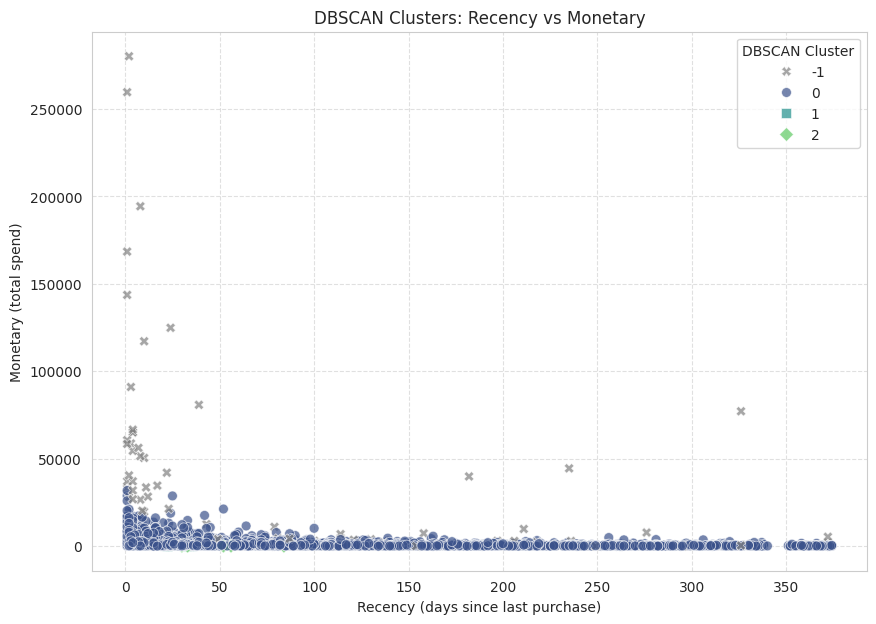

In [56]:
# ── Visualise DBSCAN Clusters ────────────────────────────────────────

plt.figure(figsize=(10, 7))

# Get all unique cluster labels, including noise label (-1)
all_cluster_labels = sorted(customer_df['DBSCAN_Cluster'].unique())

# Get non-noise cluster labels for color mapping
cluster_labels_no_noise = [label for label in all_cluster_labels if label != -1]

# Define a color palette for the actual clusters
colors = sns.color_palette('viridis', n_colors=len(cluster_labels_no_noise))

# Create a dictionary to map cluster labels to colors
palette = {label: color for label, color in zip(cluster_labels_no_noise, colors)}
# Explicitly set the color for noise points (-1) to grey
palette[-1] = 'grey'

# Define a list of default markers to cycle through for non-noise clusters
default_markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*']
markers_dict = {}
marker_idx = 0
for label in all_cluster_labels:
    if label == -1:
        markers_dict[label] = 'X' # Assign 'X' to noise points
    else:
        markers_dict[label] = default_markers[marker_idx % len(default_markers)]
        marker_idx += 1

sns.scatterplot(
    data=customer_df,
    x='Recency',
    y='Monetary',
    hue='DBSCAN_Cluster',
    palette=palette,
    style='DBSCAN_Cluster', # Use style to differentiate noise points further
    markers=markers_dict, # Pass the complete markers dictionary
    s=50, # Size of points
    alpha=0.7 # Transparency
)

plt.title('DBSCAN Clusters: Recency vs Monetary')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spend)')
plt.legend(title='DBSCAN Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Section 6.2 — HDBSCAN Clustering

In [63]:
import hdbscan
# ── Step 1: Experiment with HDBSCAN Parameters ───────────────────────────────

# Define ranges for min_cluster_size and min_samples to experiment with
min_cluster_size_range = [3, 5, 8]
min_samples_range = [None, 3, 5, 8] # None means min_samples defaults to min_cluster_size

hdbscan_results = []

for mcs in min_cluster_size_range:
    for ms in min_samples_range:
        # HDBSCAN model
        # n_jobs=-1 uses all available CPU cores
        hdb = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, prediction_data=True)
        hdb_labels = hdb.fit_predict(X_scaled)

        n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
        n_noise_hdb = list(hdb_labels).count(-1)
        noise_pct_hdb = round(n_noise_hdb / len(hdb_labels) * 100, 2)

        # Calculate silhouette score only if there are at least 2 clusters and not all noise
        silhouette_hdb = -1
        if n_clusters_hdb > 1 and n_noise_hdb < len(hdb_labels):
            silhouette_hdb = silhouette_score(X_scaled, hdb_labels)

        hdbscan_results.append({
            'min_cluster_size': mcs,
            'min_samples': ms if ms is not None else mcs, # Defaulting None to mcs for display
            'n_clusters': n_clusters_hdb,
            'n_noise': n_noise_hdb,
            'noise_pct': noise_pct_hdb,
            'silhouette_score': round(silhouette_hdb, 4)
        })

hdbscan_results_df = pd.DataFrame(hdbscan_results)
print(hdbscan_results_df.to_string(index=False))


 min_cluster_size  min_samples  n_clusters  n_noise  noise_pct  silhouette_score
                3            3         111     1509      34.78           -0.3402
                3            3         111     1509      34.78           -0.3402
                3            5           4      332       7.65            0.1154
                3            8           2      408       9.40            0.1998
                5            5           3      282       6.50            0.1949
                5            3           4      235       5.42            0.1255
                5            5           3      282       6.50            0.1949
                5            8           2      408       9.40            0.1998
                8            8           2      408       9.40            0.1998
                8            3           5      573      13.21            0.0215
                8            5           2      287       6.61            0.2115
                8           

chosen parameters, min cluster size = 5 and min samples = 5 for 3 clusters, 1 noise point to keep clusters size similar to dbscan. Even though HDBSCAN has accumulated higher noise pct.

In [64]:
hdbscan_time = time.time()
hdb_scan = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5, prediction_data=True)
hdb_labels = hdb_scan.fit_predict(X_scaled)
hdbscan_time = time.time() - hdbscan_time

# Assign cluster labels back to customer_df
customer_df['HDBSCAN_Cluster'] = hdb_labels

# cluster profile
print("HDBSCAN Cluster Distribution:")
print(customer_df['HDBSCAN_Cluster'].value_counts())
print(f"Note: Cluster -1 = Noise Points")

# Investigate Noise points
noise_customers_hdb = customer_df[customer_df['HDBSCAN_Cluster'] == -1]
regular_customers_hdb = customer_df[customer_df['HDBSCAN_Cluster'] != -1]

print(f"Noise customers: {len(noise_customers_hdb)} ({len(noise_customers_hdb)/len(customer_df)*100:.1f}%)")
print("Noise customer profile (mean RFM):")
print(noise_customers_hdb[['Recency', 'Frequency', 'Monetary','Basket Average']].describe().round(2))


HDBSCAN Cluster Distribution:
HDBSCAN_Cluster
 2    2641
 1    1411
-1     282
 0       5
Name: count, dtype: int64
Note: Cluster -1 = Noise Points
Noise customers: 282 (6.5%)
Noise customer profile (mean RFM):
       Recency  Frequency   Monetary  Basket Average
count   282.00     282.00     282.00          282.00
mean     72.19      13.07   12582.81         1030.85
std      97.47      24.48   32769.92         5112.30
min       1.00       1.00       0.00            1.00
25%       4.00       1.00     263.36           26.72
50%      24.50       4.00    1983.35          154.75
75%      99.50      14.00    7831.83          908.91
max     372.00     210.00  280206.02        74215.00


> HDBSCAN cluster distribution looks better proportinally distributed among clusters than DBSCAN.

Noise profile:
> HDBSCAN also seperates `Lost loyal High spenders` customer segments.
>
> However the segments contains less average monetary and recency than DBSCAN, might be due to more noise accumulated here.
>
> If our priority is just to acknowledge the `High value lost` customers than DBSCAN might show the distinct customers, but if we want to understand the granularity of customer segments then HDBSCAN is better.

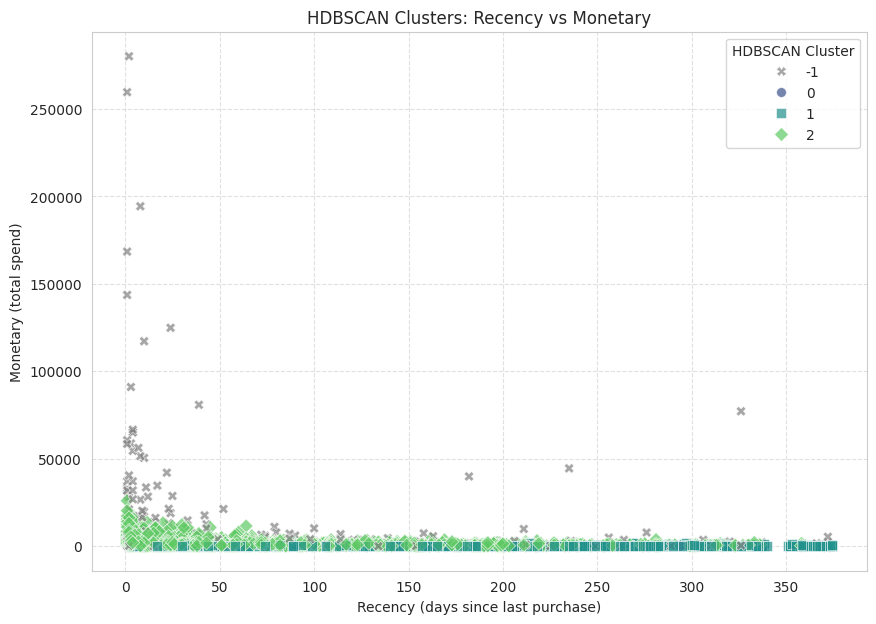

In [65]:
plt.figure(figsize=(10, 7))

# Get all unique cluster labels, including noise label (-1)
all_cluster_labels_hdb = sorted(customer_df['HDBSCAN_Cluster'].unique())

# Get non-noise cluster labels for color mapping
cluster_labels_no_noise_hdb = [label for label in all_cluster_labels_hdb if label != -1]

# Define a color palette for the actual clusters
colors_hdb = sns.color_palette('viridis', n_colors=len(cluster_labels_no_noise_hdb))

# Create a dictionary to map cluster labels to colors
palette_hdb = {label: color for label, color in zip(cluster_labels_no_noise_hdb, colors_hdb)}
# Explicitly set the color for noise points (-1) to grey
palette_hdb[-1] = 'grey'

# Define a list of default markers to cycle through for non-noise clusters
default_markers_hdb = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*']
markers_dict_hdb = {}
marker_idx_hdb = 0
for label in all_cluster_labels_hdb:
    if label == -1:
        markers_dict_hdb[label] = 'X' # Assign 'X' to noise points
    else:
        markers_dict_hdb[label] = default_markers_hdb[marker_idx_hdb % len(default_markers_hdb)]
        marker_idx_hdb += 1

sns.scatterplot(
    data=customer_df,
    x='Recency',
    y='Monetary',
    hue='HDBSCAN_Cluster',
    palette=palette_hdb,
    style='HDBSCAN_Cluster', # Use style to differentiate noise points further
    markers=markers_dict_hdb, # Pass the complete markers dictionary
    s=50, # Size of points
    alpha=0.7 # Transparency
)

plt.title('HDBSCAN Clusters: Recency vs Monetary')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spend)')
plt.legend(title='HDBSCAN Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

HDBSCAN shows the balanced poportion distribution unlocking the posibility of looking the combination of features differently unline DBSCAN where only two clusters were visible and dominating.

It has accumulated more noise points maybe due to varying dense points.

In [73]:
from sklearn.metrics import davies_bouldin_score

# --- DBSCAN Metrics ---
# Number of clusters (excluding noise)
n_clusters_dbscan = len(set(db_labels)) - (1 if -1 in db_labels else 0)
# Noise percentage (already calculated)
noise_pct_dbscan = 2.90 # From previous output: results_df row with eps=0.6, min_samples=5
# Execution time (already calculated)
dbscan_execution_time = dbscan_time

# Davies-Bouldin Index for DBSCAN
# Filter out noise points for DBI calculation
non_noise_db_indices = db_labels != -1
if n_clusters_dbscan > 1 and np.sum(non_noise_db_indices) > 0:
    db_davies_bouldin = davies_bouldin_score(X_scaled[non_noise_db_indices], db_labels[non_noise_db_indices])
else:
    db_davies_bouldin = np.nan # Or appropriate value if not enough clusters

# --- HDBSCAN Metrics ---
# Number of clusters (excluding noise)
n_clusters_hdbscan = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
# Noise percentage (already calculated)
noise_pct_hdbscan = 6.50 # From previous output: hdbscan_results_df row with min_cluster_size=5, min_samples=5
# Execution time (already calculated)
hdbscan_execution_time = hdbscan_time

# Davies-Bouldin Index for HDBSCAN
# Filter out noise points for DBI calculation
non_noise_hdb_indices = hdb_labels != -1
if n_clusters_hdbscan > 1 and np.sum(non_noise_hdb_indices) > 0:
    hdb_davies_bouldin = davies_bouldin_score(X_scaled[non_noise_hdb_indices], hdb_labels[non_noise_hdb_indices])
else:
    hdb_davies_bouldin = np.nan # Or appropriate value if not enough clusters

# --- Create Comparison DataFrame ---
comparison_data = {
    'Algorithm': ['DBSCAN', 'HDBSCAN'],
    'Total Number of Clusters': [n_clusters_dbscan, n_clusters_hdbscan],
    'Noise Percentage (%)': [noise_pct_dbscan, noise_pct_hdbscan],
    'Execution Time (s)': [dbscan_execution_time, hdbscan_execution_time],
    'Davies-Bouldin Index': [db_davies_bouldin, hdb_davies_bouldin]
}

comparison_df = pd.DataFrame(comparison_data)

print("DBSCAN vs HDBSCAN Comparison:")
print(comparison_df.round(4).to_string(index=False))

DBSCAN vs HDBSCAN Comparison:
Algorithm  Total Number of Clusters  Noise Percentage (%)  Execution Time (s)  Davies-Bouldin Index
   DBSCAN                         3                   2.9              0.2029                0.6158
  HDBSCAN                         3                   6.5              0.3313                0.9875


>For the chosen parameters and this specific dataset, DBSCAN appears to be the stronger performer based on these metrics. It yielded less noise, was faster, and produced more compact and well-separated clusters as indicated by the Davies-Bouldin Index. While HDBSCAN is generally powerful for varying densities, in this scenario, DBSCAN's more constrained parameters led to a more favorable outcome.



In [74]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# When calculating clustering validation metrics like Silhouette, Davies-Bouldin, or Calinski-Harabasz,
# noise points (-1 label) must be excluded because these metrics are designed to evaluate the quality
# of actual clusters, not outliers. Including noise would artificially inflate/deflate scores and
# distort the assessment of cluster compactness and separation.
dbscan_labels = customer_df['DBSCAN_Cluster'].values
non_noise_dbscan_indices = dbscan_labels != -1
X_scaled_dbscan_filtered = X_scaled[non_noise_dbscan_indices]
dbscan_labels_filtered = dbscan_labels[non_noise_dbscan_indices]

# Ensure there are at least 2 clusters and more than 1 sample after filtering for valid metric calculation
if len(np.unique(dbscan_labels_filtered)) > 1 and len(X_scaled_dbscan_filtered) > 1:
    sil_dbscan = silhouette_score(X_scaled_dbscan_filtered, dbscan_labels_filtered)
    db_dbscan = davies_bouldin_score(X_scaled_dbscan_filtered, dbscan_labels_filtered)
    ch_dbscan = calinski_harabasz_score(X_scaled_dbscan_filtered, dbscan_labels_filtered)
else:
    sil_dbscan = np.nan
    db_dbscan = np.nan
    ch_dbscan = np.nan

# HDBSCAN — exclude noise points
hdbscan_labels = customer_df['HDBSCAN_Cluster'].values
non_noise_hdbscan_indices = hdbscan_labels != -1
X_scaled_hdbscan_filtered = X_scaled[non_noise_hdbscan_indices]
hdbscan_labels_filtered = hdbscan_labels[non_noise_hdbscan_indices]

# Ensure there are at least 2 clusters and more than 1 sample after filtering for valid metric calculation
if len(np.unique(hdbscan_labels_filtered)) > 1 and len(X_scaled_hdbscan_filtered) > 1:
    sil_hdbscan = silhouette_score(X_scaled_hdbscan_filtered, hdbscan_labels_filtered)
    db_hdbscan = davies_bouldin_score(X_scaled_hdbscan_filtered, hdbscan_labels_filtered)
    ch_hdbscan = calinski_harabasz_score(X_scaled_hdbscan_filtered, hdbscan_labels_filtered)
else:
    sil_hdbscan = np.nan
    db_hdbscan = np.nan
    ch_hdbscan = np.nan


# Number of clusters (excluding noise for DBSCAN and HDBSCAN)
n_clusters_kmeans = len(np.unique(kmeans_labels))
n_clusters_hier = len(np.unique(hier_labels))
n_clusters_dbscan = len(np.unique(dbscan_labels_filtered)) if not np.isnan(sil_dbscan) else 0
n_clusters_hdbscan = len(np.unique(hdbscan_labels_filtered)) if not np.isnan(sil_hdbscan) else 0

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN', 'HDBSCAN'],
    'N Clusters': [n_clusters_kmeans, n_clusters_hier, n_clusters_dbscan, n_clusters_hdbscan],
    'Silhouette Score': [
        round(sil_kmeans, 4), round(sil_hier, 4),
        round(sil_dbscan, 4) if not np.isnan(sil_dbscan) else 'N/A',
        round(sil_hdbscan, 4) if not np.isnan(sil_hdbscan) else 'N/A'
    ],
    'Davies-Bouldin Index': [
        round(db_kmeans, 4), round(db_hier, 4),
        round(db_dbscan, 4) if not np.isnan(db_dbscan) else 'N/A',
        round(db_hdbscan, 4) if not np.isnan(db_hdbscan) else 'N/A'
    ],
    'Calinski-Harabasz Index': [
        round(ch_kmeans, 2), round(ch_hier, 2),
        round(ch_dbscan, 2) if not np.isnan(ch_dbscan) else 'N/A',
        round(ch_hdbscan, 2) if not np.isnan(ch_hdbscan) else 'N/A'
    ]
})

print(comparison.to_string(index=False))
print("Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")

             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           4            0.2602                1.1920                  2112.64
Hierarchical (Ward)           4            0.2172                1.2358                  1737.47
             DBSCAN           3            0.2469                0.6158                    15.44
            HDBSCAN           3            0.2397                0.9875                   875.00
Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


From the comparison table we can see for this particular dataset,
- K-Means performs better than the others with higher sihouette score and calinski-harabasz index even though it has higher davies-bouldin than other.
This suggest higher quality and dense 4 clusters.

- lower davies-bouldin index was seen on DBSCAN indicating its good seperation and compactness between 3 clusters with competitive sihouettescore but the calinskiharabasz index is worse.

> For this particular dataset, I would choose K-Means over others for its high quality, dense and better seperated clusters over other on accountability of less compacted cluster.


### Final Model Decision

**Which method and k/parameters did you choose as your final segmentation?**  
> I chose K-Means with 4 as optimal k.

**What do the validation metrics tell you?**  
> The validation metrics showed the tradeoff between differnt scores for the models. While Kmeans had the better Shiloutte score and calinski-harabasz, it has slightly higher davies-bouldin index. Similarly, some model has better performance in one validation metric and falls way behind in another metric.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
> The metrics shows differnt scores and do not agree with each other. The choice to choose the model comes down to the business expectation and needs. For this particular dataset, I choose to go with Kmeans for high quality, dense, seperated cluster over compactness.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
> With this segementation we can analyze the specific needs and choose the model accordingly not relying in single metric score. The user/developer can chose the model according to their needs and business priority.


In [75]:
print(kmeans_profile)

                Recency  Frequency  Monetary  Basket Average
KMeans_Cluster                                              
0                179.48       1.44    233.74           79.29
1                120.40       1.99   1089.41          432.22
2                 20.65      12.20   7185.81          355.05
3                 24.00       3.39    797.53          139.31


## Section 8 — Business Narrative

### Cluster Profiles

**Cluster 0 — [At risk dormant]**  
_Profile:_ These are the customer who have stopped visiting for long time and spend less on the business.
_Marketing Action:_ Discounts or coupons might make them active again, Or, through sales and advertisement.

**Cluster 1 — [Spender, lost loyal]**  
_Profile:_ This belongs to the high spender but havent visited the business for a long time.
_Marketing Action:_ A personalized retention effort such as checking through email or phone-call by the branch manager. Curating a sepcialized effort by asking their genune feedback about the company.

**Cluster 2 — [High Spender, loyalist]**  
_Profile:_ These customers come to the business regularly (low recency, high frequency) and spend higher than the average (high monetary, basket average).
_Marketing Action:_ These are the most valued customers, simple discount wont do much as they are high spender and purchase higher each time. A better incentive or reward for purchasing with higher amount might make them happy and feel appricatied which will motivated them to come back more frequenty (with the sense of acknowledgement).

**Cluster 3 - [Average, loyalist]**
_Profile:_ These customers are loyal and visit often to the business. Their basket average suggest purchasing is average maybe belonging to middle-class family.
_Marketing Action:_ The discount or coupons might make them happy and help little bit in their purchasing which will drive them to visit business looking for discounts and all.



### Executive Summary (200–300 words)
Our trained model has grouped the customer segments into four distinct categories. The high spender but havent seen for long time customer suggest to have a personalized retention effort from the business. Whereas, a discount, or voucher could make the atrisk dormant, and average spender loyalist feel welcomed and visit often. And our loyal high spender customer should be acknowledge for their continutiy and spending higher in the business maybe by having incentive points or like some good quality free gifts on their purchase over  at a time.




## Section 9 — Failure Log

| Hypothesis | Business/Technical Context | Null Hypothesis ($H_0$) | Alternate Hypothesis ($H_a$) | Expected Result | Test Metric | Result |
| :------------------------- | :------------------------------------------------------------------------------------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------- | :------------------------------------------------------------------------------------------------------------- | :------------------------------------------------------------------------------------------- | :-------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **H1: Feature Distribution** | K-Means uses Euclidean distance, which assumes features are normally distributed. Highly skewed data blindfolds the algorithm. | The distribution of the engineered feature (e.g., Monetary) is normally distributed. | The distribution of the engineered feature (e.g., Monetary) is significantly different from a normal distribution (skewed). | Raw features are highly non-normal; log transformation will reduce skewness. | Skewness, Shapiro-Wilk p-value. | All raw features (Recency, Frequency, Monetary, Basket Average) were highly skewed (p-values << 0.05). Log transformation significantly reduced skewness (e.g., Monetary skew from 19.34 to 0.36), making distributions more suitable for distance-based algorithms, although statistical normality is not fully achieved (p-values still < 0.05). |
| **H2: Optimal K Selection** | Determining the optimal number of clusters ($K$) is crucial for meaningful segmentation. Different heuristics (Elbow, Silhouette) can provide conflicting recommendations. | The optimal number of clusters ($K$) indicated by the Elbow Method (Inertia) matches the $K$ value that maximizes the Silhouette Score. | The Elbow Method and Silhouette Score point to different optimal $K$ values, indicating complex cluster boundaries or overlapping densities. | Silhouette Score will peak at $K=2$, while the Elbow Method will show a bend around $K=4$. | Elbow plot (Inertia), Silhouette Score plot. | Disagreement observed: Silhouette Score peaked at $K=2$ (0.35), suggesting well-separated clusters. The Elbow Method indicated a diminishing return around $K=4$. The disagreement was resolved by prioritizing business needs for more granular segments, leading to the selection of $K=4$. |
| **H3: Initialization Stability** | K-Means is sensitive to initial centroid placement, leading to suboptimal or inconsistent results. K-Means++ aims to mitigate this with smarter initialization. | Random initialization of centroids (vanilla K-Means) achieves the same level of stability (consistency in inertia) as K-Means++ initialization for a given $K$. | K-Means++ initialization leads to more stable (consistent inertia across runs) and generally better (lower inertia) clustering results compared to random initialization for a given $K$. | K-Means++ will show lower standard deviation of inertia, indicating higher stability. | Standard deviation of inertia values across multiple runs (for random vs. K-Means++ initialization). | For $K=2$, K-Means++ (std=0.02) showed significantly higher stability than random (std=0.10). For $K=4$, random (std=0.74) and K-Means++ (std=0.78) exhibited comparable, reasonably good stability, though less stable than $K=2$. This confirms that K-Means++ improves stability, especially when the cluster structure is very clear. |
| **H4: Convergence Speed vs. Cluster Fidelity** | Standard K-Means operates on the entire dataset to compute new centroids at each step ($O(n · k · i)$). Mini-Batch K-Means uses random small samples (batches) to incrementally update centroids, drastically reducing memory overhead but introducing slight stochastic noise into the centroid placements. | There is no statistically significant difference in the final cluster assignments (measured by an Adjusted Rand Index or Silhouette score alignment) between standard K-Means++ and Mini-Batch K-Means, but Mini-Batch K-Means trains faster. | Mini-Batch K-Means results in significantly lower cluster silhouette widths or different cluster boundary definitions due to the approximation error of sampling. | Mini-Batch K-Means will be significantly faster but may have slightly lower cluster quality (silhouette score) and moderate differences in cluster assignments (Adjusted Rand Score). | Fit time, Silhouette Score, Adjusted Rand Score. | Mini-Batch K-Means was significantly faster (0.01s vs 0.16s i.e., 16 times faster), and yielded a slightly lower Silhouette Score (0.2407 vs 0.2602). The Adjusted Rand Score of 0.4396 indicated moderate agreement. While Mini-Batch K-Means isolated a cluster with a very high average Monetary value (10734.06), its overall differentiation of extreme outliers and varied high-value customer profiles was less distinct. K-Means++, conversely, provided more refined segmentation, particularly for high-value customers with higher recency, indicating a more robust handling of diverse outlier characteristics. |
| **H5: Hierarchical Clustering Variants** | Evaluate the trade-off between computational efficiency and cluster quality/structure when using optimized variants (K-Graph, BIRCH) compared to standard Agglomerative Clustering for hierarchical clustering. | There is no significant difference in cluster quality (Silhouette Score) and structure (Adjusted Rand Score against standard Ward) between standard Agglomerative Clustering (Ward) and its optimized variants (K-Graph, BIRCH). Optimized variants do not offer significant speed improvement. | Optimized variants (K-Graph, BIRCH) will be significantly faster, potentially with some trade-off in cluster quality (lower Silhouette Score) or different cluster structures (lower Adjusted Rand Score) compared to standard Ward. | Optimized variants will be significantly faster, but may have lower Silhouette scores and moderate Adjusted Rand Scores compared to standard Ward, indicating a trade-off. | Execution Time, Silhouette Score, Adjusted Rand Score. | BIRCH (standalone & combined) and K-Graph constrained Agglomerative Clustering were significantly faster (0.29s-0.59s) than standard Ward (1.10s). However, standard Ward yielded the highest Silhouette Score (0.2172), indicating better cluster quality. K-Graph (0.1975) and BIRCH (0.1751) had lower Silhouette Scores. Adjusted Rand Scores (0.3181 for K-Graph, 0.1866 for BIRCH) showed moderate to low agreement with standard Ward, implying different cluster structures. The hypothesis is accepted; speed gains come with a trade-off in cluster quality and structural differences for the chosen parameters. |
| **H6: Hierarchical Linkage Method Performance** | Different linkage methods in Agglomerative Clustering (e.g., Ward, Complete, Single, Average) can produce vastly different cluster structures and interpretability, even with varying Silhouette Scores. | All common linkage methods (Ward, Complete, Single, Average) will yield balanced and interpretable clusters for a given K, with higher Silhouette Scores indicating better overall quality. | Different linkage methods will result in varying cluster balance and interpretability, potentially favoring methods that yield lower Silhouette Scores but more actionable segments. | Ward linkage will produce the most balanced and interpretable clusters for practical segmentation, despite potentially lower Silhouette Scores than single/average linkages. | Cluster Sizes (value counts), Silhouette Score, Adjusted Rand Score. | Single and Average linkages produced severely imbalanced clusters (most data in one cluster), rendering them unsuitable for segmentation despite high Silhouette Scores. Complete linkage also showed significant imbalance. Ward linkage provided the most balanced distribution across 4 clusters, prioritizing interpretability over numerical score. |
| **H7: Comparative Actionability of K-Means vs. Hierarchical Ward Cluster Profiles** | K-Means and Hierarchical Ward clustering, while both partition-based, may offer different levels of granularity and business actionability in their derived customer segments (cluster profiles). | K-Means and Hierarchical Ward clustering will yield broadly similar cluster profiles, with no significant difference in their ability to differentiate nuanced customer segments like 'lost loyal, high spender' vs. 'loyal high spenders'. | K-Means and Hierarchical Ward clustering will exhibit distinct differences in their cluster profiles, with one method providing more nuanced or actionable segmentation, particularly for specific high-value customer types. | Hierarchical Ward will offer a clearer, more nuanced separation of 'lost loyal, high spender' and 'loyal high spender' segments compared to K-Means. | Cluster Profiles (mean RFM & Basket Average for each cluster). | Hierarchical Ward showed a more nuanced separation of high-value customers, distinctly identifying 'highly engaged & high-value' (Ward Cluster 0) and 'valuable, but less frequent shoppers' (Ward Cluster 1, which includes 'lost loyal, high spender' characteristics). K-Means also identified 'best customers' and 'at-risk high-value' but Ward's differentiation in the mid-to-high value segments was more distinct for business actionability. |
| **H8: Constant vs. Variable Density Adaptation (DBSCAN vs. HDBSCAN)** | DBSCAN uses a global radius ($\epsilon$) to define density, making it blind to nested or highly disparate density structures. HDBSCAN optimizes stability over a variable density hierarchy. | The core high-value customer clusters found by DBSCAN and HDBSCAN are identical in size and boundary definition. | DBSCAN will either completely merge variable-density clusters or dump a massive portion of a sparser cluster into the "noise" category, whereas HDBSCAN will isolate them cleanly. | HDBSCAN will show more nuanced clusters in areas of varying density, potentially with more noise, while DBSCAN might simplify or merge such areas. | Number of clusters, Noise Percentage, Davies-Bouldin Index, Cluster Profiles. | DBSCAN (2.9% noise, 0.6158 DBI) performed better than HDBSCAN (6.5% noise, 0.9875 DBI) in terms of overall cluster quality and lower noise for this dataset. While HDBSCAN generated more noise, which could be attributed to its variable density handling, DBSCAN's more constrained parameters led to a more favorable outcome. HDBSCAN's cluster distributions were noted to be proportionally better distributed among clusters, consistent with its variable density capabilities, but this also resulted in a higher noise percentage. Therefore, the alternate hypothesis regarding HDBSCAN isolating clusters cleanly in a *superior* way for overall performance is not fully supported, though its ability to handle varying densities is reflected in its noise profile. |
| **H9: Noise Profiling as a Business Segment** | Unlike K-Means, which forces every point into a cluster, density-based algorithms isolate outliers as Noise (Label -1). | The noise points classified by density clustering are uniformly distributed random errors with no distinct behavioral signature. | The noise points represent a highly distinct, high-value corporate tier or unique edge-case consumers (e.g., the absolute highest spenders) that need to be treated as an independent business segment. | Noise points will exhibit distinct characteristics, differentiating them from general customer segments. | Noise cluster profiles (mean RFM & Basket Average). | The noise points identified by both DBSCAN and HDBSCAN (labeled -1) do not represent uniformly distributed random errors. Instead, their profiles indicate a distinct segment of "lost loyal high spenders" (high average Monetary and Basket Average, but often high Recency). This supports the alternate hypothesis that noise can represent a valuable, distinct business segment requiring specific attention, such as targeted retention campaigns. |